<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/13_lstm_comparison_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB13_FULL — Comparação LSTM por célula contra o NB11_FULL

Pipeline PPCOMP/DM — ramo `_FULL` · Borg 2019 completo por célula.

## 1. Papel do notebook

O NB13_FULL avalia uma arquitetura LSTM como experimento **complementar e defensivo** ao núcleo tabular consolidado no NB11_FULL. Ele não substitui o vencedor tabular do NB11_FULL, não redefine a formulação supervisionada e não cria uma nova linha principal de evidência. A finalidade é responder uma pergunta limitada e útil para a dissertação:

> uma arquitetura sequencial simples, treinada sobre as mesmas features causais e a mesma formulação de antecipação, melhora de forma material o desempenho observado pelo melhor modelo tabular do NB11_FULL?

No ramo `_FULL`, essa pergunta é feita **por célula Borg**. A célula é a unidade experimental; por isso, o notebook nunca concatena `a..h` como uma única série temporal para treinar a LSTM. A consolidação em `aggregate` ocorre apenas depois das métricas por célula.

## 2. Entradas esperadas

### Preferenciais — NB11_FULL

- `04-reports/99_FULL_downstream/11_FULL_model_baselines/cell_<id>/11_FULL_sequence_input_features_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/cell_<id>/11_FULL_model_input_features_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/cell_<id>/11_FULL_model_input_features_schema_cell_<id>.json`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_metrics_summary_by_cell.csv`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_winner_model.json`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_feature_sets.json`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_modelability_by_cell_scenario.csv`

### Contingência controlada — NB10_FULL

Se o NB11_FULL não tiver materializado a matriz sequencial por célula, este notebook pode reconstruir uma entrada sequencial mínima a partir do NB10_FULL, desde que o corte herdado esteja explícito:

- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_series_states_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_decisions_cell_<id>.csv`

Essa contingência fica registrada no `summary` e não é silenciosa. O caminho preferencial continua sendo consumir a base materializada pelo NB11_FULL.

## 3. Saídas geradas

Por célula, em `04-reports/99_FULL_downstream/13_FULL_lstm/cell_<id>/`:

- `13_FULL_lstm_fixed_results_cell_<id>.csv`
- `13_FULL_lstm_tscv_results_cell_<id>.csv`
- `13_FULL_lstm_fixed_results_agg_cell_<id>.csv`
- `13_FULL_lstm_tscv_results_agg_cell_<id>.csv`
- `13_FULL_lstm_scores_cell_<id>.parquet`
- `13_FULL_lstm_summary_cell_<id>.json`
- `13_FULL_lstm_feature_columns_cell_<id>.json`
- `13_FULL_lstm_decision_to_nb14_cell_<id>.json`
- `13_FULL_lstm_execution_errors_cell_<id>.csv`

Em `04-reports/99_FULL_downstream/13_FULL_lstm/aggregate/`:

- `13_FULL_lstm_fixed_results_by_cell.csv`
- `13_FULL_lstm_tscv_results_by_cell.csv`
- `13_FULL_lstm_fixed_results_agg_by_cell.csv`
- `13_FULL_lstm_tscv_results_agg_by_cell.csv`
- `13_FULL_lstm_decision_to_nb14_by_cell.csv`
- `13_FULL_lstm_scores_allcells.parquet`
- `13_FULL_lstm_summary.json`
- `13_FULL_delta_vs_canonical.csv`
- `13_FULL_artifact_manifest_sha256.csv`

## 4. Travas metodológicas

1. A unidade experimental é `cell_id`.
2. A LSTM usa os mesmos conjuntos de features do NB11_FULL (`raw_7`, `temporal_core` ou o conjunto vencedor por célula), com bloqueio explícito de leakage.
3. O corte fixo não é recalculado por fração local; usa `split` herdado ou `train_cutoff_idx` upstream.
4. `TimeSeriesSplit` continua sendo a evidência temporal principal; o corte fixo herdado é complementar e diagnóstico.
5. A saída da LSTM é interpretada como **escore relativo de risco temporal**, não como probabilidade operacional calibrada.
6. A LSTM só alimenta o NB14_FULL se superar o vencedor do NB11_FULL por margem configurada (`min_delta_f1_to_feed_nb14`, padrão `0.03`). Caso contrário, o NB14_FULL continua usando o vencedor tabular do NB11_FULL.

## 5. Diferenças em relação ao NB13 canônico

1. Entrada: artefatos do `11_FULL_model_baselines` por célula, não os artefatos canônicos em `04-reports`.
2. Execução: loop por `cell_id`, com `ACTIVE_CELLS` para piloto ou execução completa.
3. Split: corte herdado do upstream por célula; nenhuma rederivação por `floor(n × 0,80)`.
4. Saídas: todos os arquivos têm prefixo `13_FULL_` e são gravados em `13_FULL_lstm/cell_<id>` e `aggregate`.
5. Consolidação: métricas por célula e depois resumo agregado; não há treinamento sobre allcells concatenado.
6. Decisão para NB14_FULL: comparação explícita entre melhor LSTM por célula e vencedor NB11_FULL por célula.

## 6. Recomendação de execução

Para validação operacional inicial:

```python
ACTIVE_CELLS = ["a"]
RUN_MODE = "SMOKE"
```

Para execução de fechamento com custo controlado:

```python
ACTIVE_CELLS = list("abcdefgh")
RUN_MODE = "FINAL_LIGHT"
```

O modo `FULL` fica reservado para investigação adicional ou para um eventual `NB13a_FULL`, se a LSTM apresentar ganho material e estável.


[TensorFlow] Determinismo operacional habilitado quando suportado pelo backend.
NB13_FULL iniciado em: 2026-06-25 23:09:22
Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
NB13_FULL_VERSION: FINAL_LIGHT_WINNER_ONLY
DRIVE_ROOT       : /content/drive/MyDrive/Mestrado
STAGE10_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
STAGE11_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines
STAGE11_AGG_DIR  : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate
STAGE13_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13_FULL_lstm
AGGREGATE_DIR    : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13_FULL_lstm/aggregate
ACTIVE_CELLS     : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
CONFIG:
{
  "run_mode": "FINAL_LIGHT",
  "scenario_scope": "winner_only",
  "feature_sets_to_evaluate": [
    "winner_

,cell_id,scenario_label,feature_set,model,n_folds_valid,n_features,features,accuracy_tscv_mean,accuracy_tscv_std,precision_tscv_mean,precision_tscv_std,recall_tscv_mean,recall_tscv_std,f1_tscv_mean,f1_tscv_std,roc_auc_tscv_mean,roc_auc_tscv_std,average_precision_tscv_mean,average_precision_tscv_std,brier_tscv_mean,brier_tscv_std,false_alerts_per_day_tscv_mean,false_alerts_per_day_tscv_std,is_winner_tscv,status_modelagem,is_modelable,modelability_source,modelability_reason,status_modelagem_nb04_raw,status_modelagem_nb04_normalized,status_modelagem_nb11_counts,is_modelable_by_nb11_counts,official_gate_pending,official_gate_veto,n_positivos_train,n_positivos_test,min_train_positives_for_modeling,min_test_positives_for_modeling
0,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.770147,0.063925,0.313790,0.123110,0.582254,0.150741,0.398273,0.133186,0.767357,0.072995,0.418698,0.225440,0.160073,0.034441,51.163458,18.134343,True,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
1,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.823654,0.047707,0.370557,0.137546,0.444364,0.192206,0.380992,0.144285,0.746987,0.061988,0.414367,0.194118,0.128041,0.026541,30.162480,16.706465,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
2,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,random_forest,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.881892,0.035031,0.519618,0.130580,0.298824,0.220808,0.362919,0.198029,0.749326,0.073167,0.417738,0.162751,0.098581,0.022217,8.597716,3.143236,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
3,a,cell_a_W5_K24_H12_train_m2s_P1,raw_7,logistic_regression,5,7,fail_rate|n_events|n_failed|n_machines|n_colle...,0.707341,0.057746,0.255359,0.087954,0.631445,0.163162,0.355897,0.108852,0.730840,0.073514,0.372685,0.160377,0.197537,0.024180,70.895922,19.808049,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
4,a,cell_a_W5_K24_H12_train_m2s_P1,raw_7,random_forest,5,7,fail_rate|n_events|n_failed|n_machines|n_colle...,0.848287,0.028156,0.363982,0.064131,0.272785,0.122565,0.303160,0.110365,0.677676,0.049448,0.303750,0.076464,0.123333,0.015409,16.067863,4.607117,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30


[NB13_FULL_lstm] Processando cell_a...
[NB13_FULL_lstm] cell_a concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_b...
[NB13_FULL_lstm] cell_b concluída. Decisão NB14: lstm_scores_can_feed_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_c...
[NB13_FULL_lstm] cell_c concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_d...
[NB13_FULL_lstm] cell_d concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 1
[NB13_FULL_lstm] Processando cell_e...
[NB13_FULL_lstm] cell_e concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_f...
[NB13_FULL_lstm] cell_f concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_g...
[NB13_FULL_lstm] cell_g concluída. Decisão NB14: keep_nb11_scores_for_nb14. Erros registrados: 0
[NB13_FULL_lstm] Processando cell_h...
[NB13_FUL

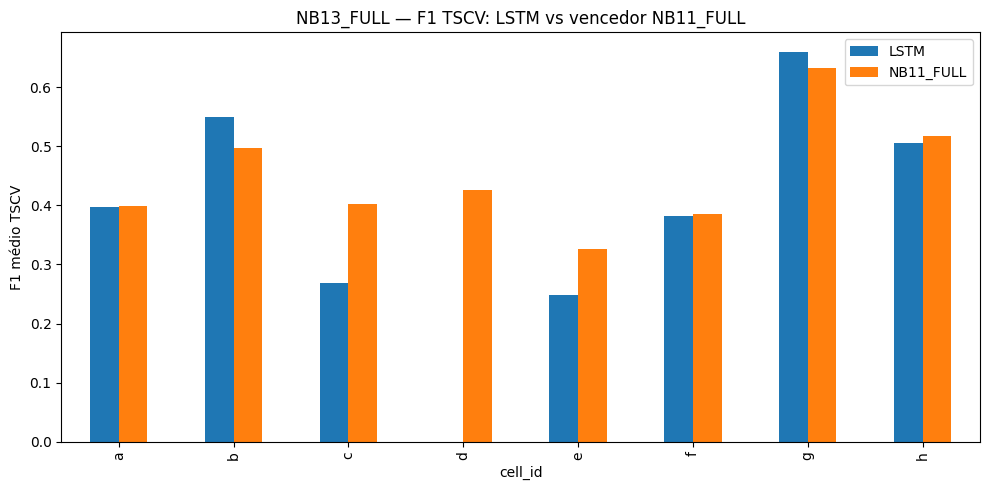

[NB13_FULL_lstm] Resumo aggregate NB13_FULL:
{
  "notebook": "NB13_FULL",
  "title": "Comparação LSTM por célula contra NB11_FULL",
  "executed_at": "2026-06-25 23:09:53",
  "active_cells": [
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h"
  ],
  "config": {
    "run_mode": "FINAL_LIGHT",
    "scenario_scope": "winner_only",
    "feature_sets_to_evaluate": [
      "winner_feature_set"
    ],
    "sequence_length": 24,
    "classification_threshold": 0.5,
    "min_delta_f1_to_feed_nb14": 0.03,
    "validation_fraction_from_train": 0.2,
    "save_keras_models": false,
    "keras_verbose": 0,
    "backup_previous_outputs": true,
    "allow_nb10_reconstruction_fallback": true,
    "fail_if_missing_inherited_split": true,
    "modelable_only": true,
    "lstm_units_grid": [
      8,
      16
    ],
    "seeds": [
      42,
      123,
      2026
    ],
    "tscv_splits": 5,
    "max_epochs": 50,
    "batch_size": 128,
    "early_stopping_patience": 8,
    "reduce_lr_pa

,cell_id,decision,reason,nb14_score_source_recommendation,robustness_interpretation,nb11_reference,nb11_f1_tscv_mean,best_lstm,best_lstm_f1_tscv_mean,best_lstm_f1_std,best_lstm_f1_se,best_lstm_n_evaluations,delta_f1_lstm_minus_nb11,delta_over_lstm_f1_se,min_delta_f1_to_feed_nb14,uncertainty_note
0,a,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'a', 'scenario_label': 'cell_a_W5_...",0.398273,"{'cell_id': 'a', 'scenario_label': 'cell_a_W5_...",0.397656,0.191735,0.049506,15.0,-0.000618,-0.012475,0.03,delta/SE é leitura descritiva baseada na varia...
1,b,lstm_scores_can_feed_nb14,LSTM superou nominalmente NB11 por delta F1=0....,nb11_primary_lstm_optional_sensitivity,ganho_nominal_acima_da_margem_mas_dentro_da_in...,"{'cell_id': 'b', 'scenario_label': 'cell_b_W5_...",0.496409,"{'cell_id': 'b', 'scenario_label': 'cell_b_W5_...",0.549358,0.155982,0.045028,12.0,0.052950,1.175923,0.03,delta/SE é leitura descritiva baseada na varia...
2,c,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'c', 'scenario_label': 'cell_c_W5_...",0.401552,"{'cell_id': 'c', 'scenario_label': 'cell_c_W5_...",0.268093,0.186806,0.048233,15.0,-0.133459,-2.766973,0.03,delta/SE é leitura descritiva baseada na varia...
3,d,keep_nb11_scores_for_nb14,LSTM sem resultado TSCV válido.,nb11_primary,sem_lstm_valida,NaN,0.426165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,e,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'e', 'scenario_label': 'cell_e_W5_...",0.326230,"{'cell_id': 'e', 'scenario_label': 'cell_e_W5_...",0.247590,0.057775,0.014917,15.0,-0.078640,-5.271666,0.03,delta/SE é leitura descritiva baseada na varia...
5,f,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'f', 'scenario_label': 'cell_f_W5_...",0.385456,"{'cell_id': 'f', 'scenario_label': 'cell_f_W5_...",0.382684,0.123312,0.031839,15.0,-0.002772,-0.087070,0.03,delta/SE é leitura descritiva baseada na varia...
6,g,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'g', 'scenario_label': 'cell_g_W5_...",0.633126,"{'cell_id': 'g', 'scenario_label': 'cell_g_W5_...",0.659834,0.144438,0.037294,15.0,0.026707,0.716131,0.03,delta/SE é leitura descritiva baseada na varia...
7,h,keep_nb11_scores_for_nb14,Ganho LSTM insuficiente ou negativo: delta F1=...,nb11_primary,sem_ganho_nominal_robusto,"{'cell_id': 'h', 'scenario_label': 'cell_h_W5_...",0.516797,"{'cell_id': 'h', 'scenario_label': 'cell_h_W5_...",0.505648,0.072963,0.018839,15.0,-0.011149,-0.591806,0.03,delta/SE é leitura descritiva baseada na varia...


,cell_id,scenario_label,feature_set,lstm_units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,brier_mean,brier_std,n_sum,n_positive_sum,n_evaluations,f1_se,recall_se,precision_se,roc_auc_se,average_precision_se,brier_se
0,a,cell_a_W5_K24_H12_train_m2s_P1,winner_temporal_core,8,0.770049,0.109429,0.337792,0.189539,0.557978,0.204268,0.397656,0.191735,0.761754,0.086876,0.434691,0.236657,0.157641,0.042083,18330.0,2409.0,15,0.049506,0.052742,0.048939,0.022431,0.061105,0.010866
1,a,cell_a_W5_K24_H12_train_m2s_P1,winner_temporal_core,16,0.783306,0.101126,0.346190,0.206373,0.518031,0.223896,0.393627,0.209025,0.741028,0.108904,0.443770,0.234705,0.150297,0.042779,18330.0,2409.0,15,0.053970,0.057810,0.053285,0.028119,0.060601,0.011045
3,b,cell_b_W5_K24_H12_train_m2s_P1,winner_temporal_core,16,0.790299,0.108543,0.473246,0.168245,0.701847,0.198695,0.549358,0.155982,0.790792,0.069125,0.595111,0.126562,0.156107,0.065294,15360.0,3402.0,12,0.045028,0.057358,0.048568,0.019955,0.036535,0.018849
2,b,cell_b_W5_K24_H12_train_m2s_P1,winner_temporal_core,8,0.788216,0.078521,0.460232,0.210761,0.689191,0.202067,0.530398,0.201554,0.778761,0.100893,0.595893,0.165378,0.155212,0.036220,15360.0,3402.0,12,0.058184,0.058332,0.060841,0.029125,0.047740,0.010456
5,c,cell_c_W5_K24_H6_train_m2s_P1,winner_temporal_core,16,0.762379,0.144779,0.244470,0.202264,0.446128,0.262409,0.268093,0.186806,0.683860,0.119955,0.309932,0.166090,0.192345,0.062436,18075.0,2070.0,15,0.048233,0.067754,0.052224,0.030972,0.042884,0.016121
4,c,cell_c_W5_K24_H6_train_m2s_P1,winner_temporal_core,8,0.546335,0.257073,0.178569,0.101225,0.653878,0.236491,0.257314,0.122197,0.631878,0.128459,0.268574,0.104045,0.244079,0.075608,18075.0,2070.0,15,0.031551,0.061062,0.026136,0.033168,0.026864,0.019522
6,e,cell_e_W5_K12_H6_train_m2s_P1,winner_temporal_core,8,0.800149,0.097481,0.170739,0.045995,0.481981,0.136980,0.247590,0.057775,0.670414,0.102927,0.289041,0.113779,0.161365,0.026895,20160.0,1314.0,15,0.014917,0.035368,0.011876,0.026576,0.029378,0.006944
7,e,cell_e_W5_K12_H6_train_m2s_P1,winner_temporal_core,16,0.774306,0.076754,0.152438,0.053269,0.524142,0.150274,0.233854,0.076173,0.697159,0.082771,0.314392,0.143981,0.159326,0.023825,20160.0,1314.0,15,0.019668,0.038801,0.013754,0.021371,0.037176,0.006152
9,f,cell_f_W5_K24_H12_train_m2s_P1,winner_temporal_core,16,0.735292,0.122518,0.450762,0.212699,0.407745,0.183356,0.382684,0.123312,0.638895,0.078307,0.394390,0.143850,0.208271,0.026786,17865.0,3528.0,15,0.031839,0.047342,0.054919,0.020219,0.037142,0.006916
8,f,cell_f_W5_K24_H12_train_m2s_P1,winner_temporal_core,8,0.626140,0.163050,0.309825,0.097797,0.538208,0.215268,0.360775,0.088840,0.631221,0.085080,0.389296,0.130675,0.225064,0.039972,17865.0,3528.0,15,0.022938,0.055582,0.025251,0.021967,0.033740,0.010321


In [1]:

# ============================================================
# NB13_FULL — Comparação LSTM por célula contra NB11_FULL
# Pipeline PPCOMP/DM — ramo _FULL
# ============================================================
# Versão proposta:
# 1. Iteração por cell_id.
# 2. Consumo preferencial da matriz sequencial do NB11_FULL.
# 3. Fallback controlado para reconstrução a partir do NB10_FULL, se necessário.
# 4. Corte fixo herdado de split/train_cutoff_idx; nunca rederivado por fração local.
# 5. LSTM como experimento complementar/defensivo.
# 6. Saídas 13_FULL_* por célula e aggregate.
# ============================================================

# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import shutil
import hashlib
import subprocess
import importlib
import warnings
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

# TensorFlow/Keras: Colab normalmente já possui TensorFlow.
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    try:
        tf.config.experimental.enable_op_determinism()
        print("[TensorFlow] Determinismo operacional habilitado quando suportado pelo backend.")
    except Exception as det_exc:
        print("[TensorFlow] Aviso: determinismo operacional não pôde ser habilitado neste backend:", repr(det_exc))
except Exception as exc:
    raise RuntimeError(
        "TensorFlow/Keras não está disponível. No Colab, selecione um runtime Python padrão "
        "ou instale tensorflow antes de executar o NB13_FULL. Detalhe: " + repr(exc)
    )

RANDOM_STATE = 42
N_SPLITS_TSCV_REFERENCE = 5
DEFAULT_THRESHOLD = 0.50
FIXED_TRAIN_FRAC_REFERENCE = 0.80  # apenas referência de sanity check; não rederiva corte
MIN_TRAIN_POSITIVES_FOR_LSTM = 30
MIN_TEST_POSITIVES_FOR_LSTM = 30
MIN_SEQUENCE_ENDPOINTS = 40
MIN_DELTA_F1_TO_FEED_NB14 = 0.03

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB13_FULL iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Bootstrap, caminhos oficiais _FULL e travas de herança
# ============================================================

try:
    IN_COLAB = "google.colab" in str(get_ipython())
except Exception:
    IN_COLAB = False

if IN_COLAB and not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
elif Path("/content/drive/MyDrive").exists():
    print("[Bootstrap] Google Drive já montado.")

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_ROOT = MYDRIVE_ROOT / "Mestrado"
REPO_DIR = DRIVE_ROOT / "PPCOMP_DM"
NOTEBOOKS_DIR = MYDRIVE_ROOT / "Colab Notebooks"
CANONICAL_NOTEBOOK = NOTEBOOKS_DIR / "13_lstm_comparison.ipynb"
FULL_NOTEBOOK = NOTEBOOKS_DIR / "13_lstm_comparison_FULL.ipynb"
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

# O repositório não é exigido para a execução, mas é útil para diff e rastreabilidade.
if REPO_DIR.exists():
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)
    try:
        os.chdir(str(REPO_DIR))
        if str(REPO_DIR) not in os.sys.path:
            os.sys.path.insert(0, str(REPO_DIR))
        importlib.invalidate_caches()
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível usar REPO_DIR como CWD:", e)

FULL_CELLS = list("abcdefgh")
# ACTIVE_CELLS = ["a"]  # Piloto seguro. Para fechamento: ACTIVE_CELLS = FULL_CELLS[:]
ACTIVE_CELLS = FULL_CELLS[:]

RUN_MODE = "FINAL_LIGHT"  # "SMOKE", "FINAL_LIGHT" ou "FULL"

CONFIG = {
    "run_mode": RUN_MODE,
    "scenario_scope": "winner_only",  # winner_only | winner_plus_10min | all_available_for_cell
    "feature_sets_to_evaluate": ["winner_feature_set"], # "feature_sets_to_evaluate": ["winner_feature_set", "raw_7", "temporal_core"],
    "sequence_length": 24,
    "classification_threshold": DEFAULT_THRESHOLD,
    "min_delta_f1_to_feed_nb14": MIN_DELTA_F1_TO_FEED_NB14,
    "validation_fraction_from_train": 0.20,
    "save_keras_models": False,
    "keras_verbose": 0,
    "backup_previous_outputs": True,
    "allow_nb10_reconstruction_fallback": True,
    "fail_if_missing_inherited_split": True,
    "modelable_only": True,
}

if RUN_MODE == "SMOKE":
    CONFIG.update({
        "lstm_units_grid": [8],
        "seeds": [42],
        "tscv_splits": 2,
        "max_epochs": 8,
        "batch_size": 128,
        "early_stopping_patience": 3,
        "reduce_lr_patience": 2,
        "feature_sets_to_evaluate": ["winner_feature_set"],
        "keras_verbose": 1,
    })
elif RUN_MODE == "FINAL_LIGHT":
    CONFIG.update({
        "lstm_units_grid": [8, 16],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 50,
        "batch_size": 128,
        "early_stopping_patience": 8,
        "reduce_lr_patience": 4,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "feature_sets_to_evaluate": ["winner_feature_set"],
        "scenario_scope": "winner_only",
        "modelable_only": True,
    })
elif RUN_MODE == "FULL":
    CONFIG.update({
        "lstm_units_grid": [8, 16, 32],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 100,
        "batch_size": 128,
        "early_stopping_patience": 12,
        "reduce_lr_patience": 5,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "scenario_scope": "winner_plus_10min",
    })
else:
    raise ValueError(f"RUN_MODE inválido: {RUN_MODE}")

# Trava metodológica da execução oficial NB13_FULL:
# comparar LSTM apenas contra o feature set vencedor do NB11_FULL.
CONFIG["feature_sets_to_evaluate"] = ["winner_feature_set"]
CONFIG["scenario_scope"] = "winner_only"
CONFIG["modelable_only"] = True

NB13_FULL_VERSION = "FINAL_LIGHT_WINNER_ONLY"
# Sanidade obrigatória para evitar executar uma versão antiga ou escopo exploratório.
assert RUN_MODE == "FINAL_LIGHT", f"NB13_FULL oficial deve rodar FINAL_LIGHT; atual={RUN_MODE}"
assert ACTIVE_CELLS == FULL_CELLS[:], f"NB13_FULL oficial deve rodar as 8 células; atual={ACTIVE_CELLS}"
assert CONFIG.get("feature_sets_to_evaluate") == ["winner_feature_set"], CONFIG.get("feature_sets_to_evaluate")
assert CONFIG.get("scenario_scope") == "winner_only", CONFIG.get("scenario_scope")
assert CONFIG.get("modelable_only") is True, CONFIG.get("modelable_only")
print("NB13_FULL_VERSION:", NB13_FULL_VERSION)

FULL_MODEL_FACING_PARQUET = (

    DRIVE_ROOT
    / "02-datasets"
    / "99-full"
    / "03-model-facing"
    / "window_5min_series_allcells_model_facing_000000000000.parquet"
)
CANONICAL_WINDOW_5MIN_SERIES = DRIVE_ROOT / "02-datasets" / "03-features" / "window_5min_series.parquet"

FULL_REPORTS_DIR = DRIVE_ROOT / "04-reports" / "99_FULL_downstream"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE11_DIR = FULL_REPORTS_DIR / "11_FULL_model_baselines"
STAGE11_AGG_DIR = STAGE11_DIR / "aggregate"
STAGE13_DIR = FULL_REPORTS_DIR / "13_FULL_lstm"
AGGREGATE_DIR = STAGE13_DIR / "aggregate"
FIGURES_DIR = AGGREGATE_DIR / "figures"
BACKUP_BASE_DIR = AGGREGATE_DIR / "_backup_previous_artifacts"















for p in [FULL_REPORTS_DIR, STAGE13_DIR, AGGREGATE_DIR, FIGURES_DIR, BACKUP_BASE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT       :", DRIVE_ROOT)
print("STAGE10_DIR      :", STAGE10_DIR)
print("STAGE11_DIR      :", STAGE11_DIR)
print("STAGE11_AGG_DIR  :", STAGE11_AGG_DIR)
print("STAGE13_DIR      :", STAGE13_DIR)
print("AGGREGATE_DIR    :", AGGREGATE_DIR)
print("ACTIVE_CELLS     :", ACTIVE_CELLS)
print("CONFIG:")
print(json.dumps(CONFIG, ensure_ascii=False, indent=2, default=str))

assert "03-features" not in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR não pode apontar para 03-features."
assert FULL_MODEL_FACING_PARQUET != CANONICAL_WINDOW_5MIN_SERIES, "Entrada FULL não pode ser a série canônica."
# O aggregate do NB11_FULL é preferencial, mas pode estar em pasta alternativa ou ainda não ter sido consolidado.
# Não abortar aqui: a etapa 3 faz descoberta robusta e produz diagnóstico acionável.
# REV4: usar print neste ponto, pois log() é definido mais adiante no bootstrap.
if not STAGE11_AGG_DIR.exists():
    print(f"[AVISO] Aggregate preferencial do NB11_FULL não existe: {STAGE11_AGG_DIR}")
    print("[AVISO] O NB13_FULL tentará localizar os artefatos 11_FULL_* por busca recursiva em 99_FULL_downstream.")
if CONFIG.get("allow_nb10_reconstruction_fallback", True) and not STAGE10_DIR.exists():
    print(f"[AVISO] Fallback NB10_FULL habilitado, mas STAGE10_DIR não existe: {STAGE10_DIR}")

CANONICAL_RAW_7 = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
]

CANONICAL_TEMPORAL_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
temporal_core = CANONICAL_TEMPORAL_CORE[:]
assert len(temporal_core) == 14
assert temporal_core == CANONICAL_TEMPORAL_CORE

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")


def log(msg: str) -> None:
    print(f"[NB13_FULL_lstm] {msg}", flush=True)


# ============================================================
# 2. Utilidades gerais
# ============================================================

def json_ready(obj):
    """Converte objetos NumPy/Pandas/Path para JSON seguro."""
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (pd.Timestamp,)):
        return obj.isoformat()
    if obj is pd.NA:
        return None
    if isinstance(obj, float) and math.isnan(obj):
        return None
    return obj


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(json_ready(obj), f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(path, index=False)
        return path
    except Exception as exc:
        fallback = path.with_suffix(".csv")
        df.to_csv(fallback, index=False)
        log(f"[AVISO] Falha ao salvar parquet {path.name}; salvo CSV {fallback.name}. Detalhe: {exc}")
        return fallback


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def build_artifact_manifest(root_dir: Path, out_file: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(root_dir.rglob("*")):
        if not p.is_file():
            continue
        if p.resolve() == out_file.resolve():
            continue
        rows.append({
            "relative_path": str(p.relative_to(root_dir)),
            "size_bytes": int(p.stat().st_size),
            "mtime_iso": datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec="seconds"),
            "sha256": sha256_file(p),
        })
    df = pd.DataFrame(rows)
    save_csv(df, out_file)
    return df


def find_existing(candidates, required=True, label="arquivo"):
    for p in candidates:
        if p is not None and Path(p).exists():
            return Path(p)
    if required:
        msg = f"{label} obrigatório não encontrado. Candidatos:\n" + "\n".join(str(c) for c in candidates if c is not None)
        raise FileNotFoundError(msg)
    return None




def dedupe_paths(paths):
    out = []
    seen = set()
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        key = str(pp)
        if key not in seen:
            out.append(pp)
            seen.add(key)
    return out


def find_stage11_artifact(filenames, required=True, label="artefato NB11_FULL"):
    """Localiza artefatos NB11_FULL mesmo quando aggregate não está na pasta preferencial.

    Ordem de preferência:
      1. STAGE11_DIR/aggregate/<filename>;
      2. qualquer subpasta de STAGE11_DIR;
      3. busca controlada em 99_FULL_downstream.
    """
    if isinstance(filenames, str):
        filenames = [filenames]
    candidates = []
    for name in filenames:
        candidates.append(STAGE11_AGG_DIR / name)
    if STAGE11_DIR.exists():
        for name in filenames:
            candidates.extend(sorted(STAGE11_DIR.rglob(name)))
    if FULL_REPORTS_DIR.exists():
        for name in filenames:
            candidates.extend(sorted(FULL_REPORTS_DIR.rglob(name)))

    candidates = dedupe_paths(candidates)
    # Preferir explicitamente artefatos que pertençam ao NB11, evitando qualquer colisão futura.
    candidates = sorted(
        candidates,
        key=lambda p: (
            0 if "11_FULL_model_baselines" in str(p) and "aggregate" in p.parts else
            1 if "11_FULL_model_baselines" in str(p) else 2,
            len(str(p)),
            str(p),
        ),
    )
    found = find_existing(candidates, required=False, label=label)
    if found is not None:
        if found.parent != STAGE11_AGG_DIR:
            log(f"[AVISO] {label} localizado fora do aggregate preferencial: {found}")
        return found
    if required:
        diag = {
            "label": label,
            "filenames": filenames,
            "stage11_dir_exists": STAGE11_DIR.exists(),
            "stage11_agg_dir_exists": STAGE11_AGG_DIR.exists(),
            "stage11_dir": str(STAGE11_DIR),
            "stage11_agg_dir": str(STAGE11_AGG_DIR),
            "checked_candidates": [str(c) for c in candidates[:80]],
        }
        raise FileNotFoundError(
            f"{label} obrigatório não encontrado. Diagnóstico:\n" + json.dumps(json_ready(diag), ensure_ascii=False, indent=2)
        )
    return None

def parse_features_value(value):
    """Normaliza listas de features vindas de JSON, CSV ou string compactada.

    O NB11_FULL pode serializar a lista de features em CSV como:
      - lista JSON: ["fail_rate", "n_events", ...]
      - texto separado por vírgula: fail_rate,n_events,...
      - texto separado por pipe: fail_rate|n_events|...

    A versão anterior tratava a terceira forma como uma única coluna literal, o que
    fazia o NB13_FULL procurar uma coluna chamada "fail_rate|n_events|...".
    Esta função achata recursivamente listas/tuplas e preserva a ordem sem duplicar.
    """
    def _dedupe(seq):
        out = []
        seen = set()
        for item in seq:
            s = str(item).strip().strip('"').strip("'")
            if s and s not in seen:
                seen.add(s)
                out.append(s)
        return out

    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        flattened = []
        for item in value:
            flattened.extend(parse_features_value(item))
        return _dedupe(flattened)
    try:
        if pd.isna(value):
            return []
    except Exception:
        pass
    if isinstance(value, str):
        v = value.strip()
        if not v or v.lower() in {"nan", "none", "null"}:
            return []
        try:
            parsed = json.loads(v)
            if isinstance(parsed, (list, tuple, set)):
                return parse_features_value(parsed)
        except Exception:
            pass
        if (v.startswith("[") and v.endswith("]")) or (v.startswith("(") and v.endswith(")")):
            try:
                import ast
                parsed = ast.literal_eval(v)
                if isinstance(parsed, (list, tuple, set)):
                    return parse_features_value(parsed)
            except Exception:
                pass
        for sep in ["|", ",", ";"]:
            if sep in v:
                return _dedupe([x for x in v.split(sep)])
        return _dedupe([v])
    return _dedupe([value])


def _to_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes", "y", "sim", "s"])


def find_col(df: pd.DataFrame, candidates, required=False, label="coluna"):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = str(cand).strip().lower()
        if key in lower_map:
            return lower_map[key]
    if required:
        raise ValueError(f"{label} obrigatória não encontrada. Candidatas: {candidates}. Colunas disponíveis: {list(df.columns)}")
    return None


def parse_scenario_label(label: str) -> dict:
    """Parser robusto e case-insensitive para labels W/K/H/P e família de limiar.

    Observação: P de persistência é reconhecido apenas por token (_P1_), para não
    confundir com limiares percentílicos P95/P99.
    """
    s = str(label)
    su = s.upper()
    out = {"scenario_label": s}
    patterns = {
        "window_minutes": r"(?:^|_)W(\d+)(?:_|$)",
        "k_before_after": r"(?:^|_)K(\d+)(?:_|$)",
        "horizon_h": r"(?:^|_)H(\d+)(?:_|$)",
        "persistence_min_windows": r"(?:^|_)P(\d+)(?:_|$)",
    }
    for k, pat in patterns.items():
        m = re.search(pat, su)
        out[k] = int(m.group(1)) if m else None

    if "TRAIN_M2S" in su or "TRAIN_MU_PLUS_2SIGMA" in su:
        out["threshold_family"] = "train_m2s"
    elif "GLOBAL_M2S" in su or "GLOBAL_MU_PLUS_2SIGMA" in su:
        out["threshold_family"] = "global_m2s"
    elif "TRAIN_P95" in su or re.search(r"(?:^|_)P95(?:_|$)", su):
        out["threshold_family"] = "train_p95"
    elif "GLOBAL_P95" in su:
        out["threshold_family"] = "global_p95"
    elif "TRAIN_P99" in su or re.search(r"(?:^|_)P99(?:_|$)", su):
        out["threshold_family"] = "train_p99"
    elif "GLOBAL_P99" in su:
        out["threshold_family"] = "global_p99"
    else:
        out["threshold_family"] = "unknown"
    return out


def get_h_windows_from_label(label: str, default=12) -> int:
    parsed = parse_scenario_label(label)
    return int(parsed.get("horizon_h") or default)


def get_window_minutes_from_label(label: str, default=5) -> int:
    parsed = parse_scenario_label(label)
    return int(parsed.get("window_minutes") or default)


# ============================================================
# 3. Carregamento dos artefatos NB11_FULL aggregate
# ============================================================

PATH_NB11_WINNER = find_stage11_artifact(["11_FULL_winner_model.json", "11_FULL_winner_by_cell.json"], required=True, label="winner NB11_FULL")
PATH_NB11_SUMMARY = find_stage11_artifact(["11_FULL_nb11_summary.json", "11_FULL_summary.json"], required=False, label="summary NB11_FULL")
PATH_NB11_METRICS_SUMMARY = find_stage11_artifact(["11_FULL_metrics_summary_by_cell.csv", "11_FULL_metrics_by_cell.csv", "11_FULL_model_metrics_by_cell.csv"], required=True, label="metrics NB11_FULL")
PATH_NB11_BASELINES_SUMMARY = find_stage11_artifact(["11_FULL_baselines_summary_by_cell.csv", "11_FULL_baselines_by_cell.csv"], required=False, label="baselines NB11_FULL")
PATH_NB11_MODELABILITY = find_stage11_artifact(["11_FULL_modelability_by_cell_scenario.csv", "11_FULL_modelability_by_cell.csv"], required=False, label="modelability NB11_FULL")
PATH_NB11_FEATURE_SETS = find_stage11_artifact(["11_FULL_feature_sets.json"], required=False, label="feature sets NB11_FULL")
PATH_NB11_SCHEMA_AGG = find_stage11_artifact(["11_FULL_model_input_features_schema.json", "11_FULL_sequence_input_features_schema.json"], required=False, label="schema NB11_FULL aggregate")

winner_global = read_json(PATH_NB11_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
df_nb11_metrics_summary = pd.read_csv(PATH_NB11_METRICS_SUMMARY)
df_nb11_modelability = pd.read_csv(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else pd.DataFrame()
feature_sets_from_nb11 = read_json(PATH_NB11_FEATURE_SETS) if PATH_NB11_FEATURE_SETS else {}
schema_agg = read_json(PATH_NB11_SCHEMA_AGG) if PATH_NB11_SCHEMA_AGG else {}

if not feature_sets_from_nb11:
    feature_sets_from_nb11 = {
        "raw_7": CANONICAL_RAW_7,
        "temporal_core": CANONICAL_TEMPORAL_CORE,
        "feature_sets_by_scenario": {},
    }

assert "cell_id" in df_nb11_metrics_summary.columns, "11_FULL_metrics_summary_by_cell.csv deve conter cell_id."
log("Artefatos NB11_FULL aggregate carregados.")
display(df_nb11_metrics_summary.head())


# ============================================================
# 4. Seleção do vencedor NB11_FULL por célula
# ============================================================

def select_nb11_winner_for_cell(cell_id: str) -> dict:
    """Seleciona o vencedor do NB11_FULL para a célula.

    Preferência metodológica:
      1. vencedor TSCV da própria célula e modelável;
      2. vencedor TSCV da própria célula, mesmo sem flag modelável;
      3. melhor linha disponível da célula;
      4. vencedor global como fallback explícito.
    """
    df = df_nb11_metrics_summary.copy()
    d = df[df["cell_id"].astype(str) == str(cell_id)].copy()
    fallback_used = False
    fallback_reason = ""

    if not d.empty and "is_winner_tscv" in d.columns:
        d_w = d[_to_bool_series(d["is_winner_tscv"])].copy()
    else:
        d_w = pd.DataFrame()

    if not d_w.empty and "is_modelable" in d_w.columns:
        d_modelable = d_w[_to_bool_series(d_w["is_modelable"])].copy()
    else:
        d_modelable = pd.DataFrame()

    if not d_modelable.empty:
        candidates = d_modelable
        selection_scope = "cell_winner_modelable_only"
    elif not d_w.empty:
        candidates = d_w
        selection_scope = "cell_winner_all_status_fallback"
    elif not d.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in d.columns]
        candidates = d.sort_values(sort_cols, ascending=[False] * len(sort_cols)) if sort_cols else d
        selection_scope = "cell_best_available_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem linha is_winner_tscv; selecionado melhor disponível por métrica."
    else:
        candidates = pd.DataFrame()
        selection_scope = "global_winner_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem métricas no NB11_FULL; usado winner global."

    if not candidates.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in candidates.columns]
        row = candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0] if sort_cols else candidates.iloc[0]
        feature_set = str(row.get("feature_set", winner_global.get("feature_set", "temporal_core")))
        model = str(row.get("model", winner_global.get("model", "unknown")))
        features = parse_features_value(row.get("features", None))
        if not features and feature_set in feature_sets_from_nb11:
            features = parse_features_value(feature_sets_from_nb11[feature_set])
        if not features:
            features = parse_features_value(winner_global.get("features", []))
        f1_ref = float(row.get("f1_tscv_mean", np.nan)) if "f1_tscv_mean" in row.index else np.nan
        scenario_label = str(row.get("scenario_label", winner_global.get("scenario_label", "")))
        out = {
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "features": features,
            "f1_tscv_mean": f1_ref,
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_metrics_summary_by_cell.csv",
        }
    else:
        out = {
            "cell_id": str(cell_id),
            "scenario_label": str(winner_global.get("scenario_label", "")),
            "feature_set": str(winner_global.get("feature_set", "temporal_core")),
            "model": str(winner_global.get("model", "unknown")),
            "features": parse_features_value(winner_global.get("features", [])),
            "f1_tscv_mean": float(winner_global.get("f1_tscv_mean", np.nan)),
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_winner_model.json",
        }

    if not out["features"]:
        # Feature set can still be resolved later; keep explicit warning.
        log(f"[AVISO] Não foi possível resolver features do vencedor NB11_FULL para cell_{cell_id}; feature_sets_to_evaluate controlarão a execução.")
    return out


def is_modelable_by_nb11(cell_id: str, scenario_label: str) -> dict:
    if df_nb11_modelability.empty:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "11_FULL_modelability ausente; execução permitida com validação local."}
    df = df_nb11_modelability.copy()
    if "cell_id" not in df.columns:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "modelability sem cell_id; execução permitida com validação local."}
    sc_col = find_col(df, ["scenario_label", "scenario_id", "scenario"], required=False)
    d = df[df["cell_id"].astype(str).eq(str(cell_id))].copy()
    if sc_col:
        d2 = d[d[sc_col].astype(str).eq(str(scenario_label))].copy()
        if not d2.empty:
            d = d2
    if d.empty:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "sem linha específica em modelability; execução permitida com validação local."}
    row = d.iloc[0]
    if "is_modelable" in d.columns:
        ok = bool(_to_bool_series(pd.Series([row.get("is_modelable")])).iloc[0])
    elif "status_modelagem" in d.columns:
        ok = str(row.get("status_modelagem", "")).lower().startswith("model")
    else:
        ok = True
    return {
        "is_modelable": ok,
        "status_modelagem": str(row.get("status_modelagem", "modelavel" if ok else "descritiva")),
        "reason": str(row.get("modelability_reason", row.get("justificativa", "modelability NB11_FULL"))),
    }


# ============================================================
# 5. Localização de entradas por célula
# ============================================================

def resolve_schema_for_cell(cell_id: str):
    cell_dir = STAGE11_DIR / f"cell_{cell_id}"
    candidates = [
        cell_dir / f"11_FULL_model_input_features_schema_cell_{cell_id}.json",
        cell_dir / f"11_FULL_sequence_input_features_schema_cell_{cell_id}.json",
        cell_dir / "11_FULL_model_input_features_schema.json",
        STAGE11_AGG_DIR / "11_FULL_model_input_features_schema.json",
    ]
    path = find_existing(candidates, required=False, label=f"schema NB11_FULL cell_{cell_id}")
    return read_json(path) if path else schema_agg.copy()


def resolve_cell_input_path(cell_id: str) -> dict:
    cell_dir = STAGE11_DIR / f"cell_{cell_id}"
    direct_candidates = [
        cell_dir / f"11_FULL_sequence_input_features_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_model_input_features_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_sequence_input_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_model_input_cell_{cell_id}.parquet",
    ]
    for p in direct_candidates:
        if p.exists():
            return {"path": p, "kind": "cell_parquet", "source_stage": "NB11_FULL"}

    if cell_dir.exists():
        patterns = ["*sequence*features*.parquet", "*model*input*features*.parquet", "*sequence*.parquet", "*model_input*.parquet"]
        for pattern in patterns:
            found = sorted(cell_dir.glob(pattern))
            if found:
                return {"path": found[0], "kind": "cell_parquet_glob", "source_stage": "NB11_FULL"}

    aggregate_candidates = [
        STAGE11_AGG_DIR / "11_FULL_sequence_input_features_allcells.parquet",
        STAGE11_AGG_DIR / "11_FULL_model_input_features_allcells.parquet",
        STAGE11_AGG_DIR / "11_FULL_sequence_input_features.parquet",
        STAGE11_AGG_DIR / "11_FULL_model_input_features.parquet",
    ]
    for p in aggregate_candidates:
        if p.exists():
            return {"path": p, "kind": "aggregate_allcells_parquet", "source_stage": "NB11_FULL"}

    return {"path": None, "kind": "missing", "source_stage": None}


def resolve_nb10_cell_files(cell_id: str) -> dict:
    cell_dir = STAGE10_DIR / f"cell_{cell_id}"
    files = {
        "advanced_json": cell_dir / f"10_FULL_advanced_to_nb11_cell_{cell_id}.json",
        "states_parquet": cell_dir / f"10_FULL_scenario_series_states_cell_{cell_id}.parquet",
        "episodes_parquet": cell_dir / f"10_FULL_scenario_episodes_cell_{cell_id}.parquet",
        "decisions_csv": cell_dir / f"10_FULL_scenario_decisions_cell_{cell_id}.csv",
    }
    missing_required = [str(files[k]) for k in ["states_parquet", "decisions_csv"] if not files[k].exists()]
    if missing_required:
        raise FileNotFoundError(f"Arquivos esperados do NB10_FULL não encontrados para cell_{cell_id}:\n" + "\n".join(missing_required))
    return files


def load_sequence_or_reconstruct(cell_id: str, winner_ctx: dict) -> dict:
    info = resolve_cell_input_path(cell_id)
    schema = resolve_schema_for_cell(cell_id)
    if info["path"] is not None:
        df = pd.read_parquet(info["path"])
        if info["kind"] == "aggregate_allcells_parquet":
            if "cell_id" not in df.columns:
                raise ValueError(f"Arquivo aggregate {info['path']} não contém cell_id.")
            df = df[df["cell_id"].astype(str).eq(str(cell_id))].copy()
        if df.empty:
            raise ValueError(f"Entrada NB11_FULL vazia para cell_{cell_id}: {info['path']}")
        if "cell_id" not in df.columns:
            df["cell_id"] = str(cell_id)
        observed_cells = sorted(df["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_cells == [str(cell_id)], f"Entrada da cell_{cell_id} contém células inesperadas: {observed_cells}"
        return {
            "df": df,
            "schema": schema,
            "input_path": str(info["path"]),
            "input_kind": info["kind"],
            "source_stage": "NB11_FULL",
            "reconstructed_from_nb10": False,
        }

    if not CONFIG.get("allow_nb10_reconstruction_fallback", True):
        raise FileNotFoundError(f"Matriz sequencial NB11_FULL não encontrada para cell_{cell_id} e fallback NB10 está desabilitado.")

    log(f"[AVISO] Matriz sequencial NB11_FULL ausente para cell_{cell_id}; reconstruindo entrada mínima a partir do NB10_FULL.")
    nb10_files = resolve_nb10_cell_files(cell_id)
    df_states = pd.read_parquet(nb10_files["states_parquet"])
    df_decisions = pd.read_csv(nb10_files["decisions_csv"])
    if "cell_id" not in df_states.columns:
        df_states["cell_id"] = str(cell_id)
    df_states = df_states[df_states["cell_id"].astype(str).eq(str(cell_id))].copy()
    if df_states.empty:
        raise ValueError(f"states NB10_FULL vazio para cell_{cell_id}.")
    return {
        "df": df_states,
        "schema": schema,
        "input_path": str(nb10_files["states_parquet"]),
        "decisions_path": str(nb10_files["decisions_csv"]),
        "input_kind": "reconstructed_from_nb10_states",
        "source_stage": "NB10_FULL_RECONSTRUCTION_FALLBACK",
        "reconstructed_from_nb10": True,
        "df_decisions": df_decisions,
    }


# ============================================================
# 6. Features, prevenção de leakage e preparação da série
# ============================================================

FORBIDDEN_EXACT_BASE = {
    "y", "y_nb11", "y_nb12", "y_nb13", "y_lstm", "target", "label",
    "state", "operational_state", "estado", "phase", "episode_state",
    "is_critical", "is_critical_raw", "is_during", "is_before", "is_after", "is_normal",
    "horizon_complete", "eligible_supervised", "endpoint_eligible", "endpoint_eligibility",
    "window_minutes", "k_before_after", "horizon_h", "k_minutes", "h_minutes",
    "threshold", "threshold_value", "mu", "sigma", "persistence_min_windows", "persistence_minutes",
    "row_position", "bucket_id", "bucket_start_us", "bucket_start", "bucket_start_dt", "bucket_start_datetime",
    "timestamp", "datetime", "time", "window_start", "dt",
    "cell_id", "scenario", "scenario_id", "scenario_label", "scenario_name", "scenario_key", "cenario",
    "split", "train_cutoff_idx", "train_cutoff_bucket_id",
}

FORBIDDEN_PATTERNS = [
    r"^y$", r"^y_", r"target", r"label", r"future", r"will_", r"ahead",
    r"state", r"estado", r"phase", r"during", r"before", r"after", r"episode", r"critical", r"normal",
    r"eligible", r"horizon", r"persistence", r"threshold", r"limiar", r"scenario", r"cenario",
    r"bucket_start", r"timestamp", r"datetime", r"row_position",
    r"(^|_)score($|_)", r"(^|_)scores($|_)", r"(^|_)prob($|_)", r"(^|_)proba($|_)",
    r"(^|_)pred($|_)", r"(^|_)prediction($|_)", r"(^|_)fold($|_)", r"(^|_)split($|_)",
]

ALLOWED_FEATURES_FROM_NB11 = set(CANONICAL_RAW_7 + CANONICAL_TEMPORAL_CORE)
for key in ["raw_7", "temporal_core", "temporal_full"]:
    value = feature_sets_from_nb11.get(key)
    if isinstance(value, list):
        ALLOWED_FEATURES_FROM_NB11.update(value)
for scenario, fs_dict in feature_sets_from_nb11.get("feature_sets_by_scenario", {}).items():
    if isinstance(fs_dict, dict):
        for fs_name, fs_info in fs_dict.items():
            if isinstance(fs_info, dict):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info.get("features", []))
            elif isinstance(fs_info, list):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info)


def is_forbidden_feature(col, target_col=None, eligibility_col=None):
    c = str(col)
    lc = c.lower()
    forbidden_exact = set(FORBIDDEN_EXACT_BASE)
    if target_col:
        forbidden_exact.add(str(target_col))
    if eligibility_col:
        forbidden_exact.add(str(eligibility_col))
    if lc in {str(x).lower() for x in forbidden_exact}:
        return True
    if c in ALLOWED_FEATURES_FROM_NB11:
        return False
    for pattern in FORBIDDEN_PATTERNS:
        if re.search(pattern, lc):
            return True
    return False


def get_feature_set_for_scenario(scenario_label, feature_set_name, winner_ctx=None):
    if feature_set_name == "winner_feature_set":
        return list(winner_ctx.get("features", [])) if winner_ctx else []

    by_scenario = feature_sets_from_nb11.get("feature_sets_by_scenario", {})
    if scenario_label in by_scenario and feature_set_name in by_scenario[scenario_label]:
        fs = by_scenario[scenario_label][feature_set_name]
        if isinstance(fs, dict):
            return list(fs.get("features", []))
        if isinstance(fs, list):
            return list(fs)

    if feature_set_name in feature_sets_from_nb11 and isinstance(feature_sets_from_nb11[feature_set_name], list):
        return list(feature_sets_from_nb11[feature_set_name])

    if feature_set_name == "raw_7":
        return CANONICAL_RAW_7[:]
    if feature_set_name == "temporal_core":
        return CANONICAL_TEMPORAL_CORE[:]
    return []


def add_causal_temporal_features(df: pd.DataFrame, fail_rate_col="fail_rate") -> pd.DataFrame:
    if fail_rate_col not in df.columns:
        raise ValueError(f"Coluna {fail_rate_col} ausente para engenharia temporal causal.")
    df = df.copy()
    fr = pd.to_numeric(df[fail_rate_col], errors="coerce").fillna(0).astype(float)
    df[fail_rate_col] = fr
    for lag in [1, 2, 3]:
        col = f"lag_{lag}"
        if col not in df.columns:
            df[col] = fr.shift(lag)
    if "rolling_mean_1h" not in df.columns:
        df["rolling_mean_1h"] = fr.rolling(window=12, min_periods=1).mean()
    if "rolling_std_1h" not in df.columns:
        df["rolling_std_1h"] = fr.rolling(window=12, min_periods=2).std().fillna(0)
    if "pct_change" not in df.columns:
        df["pct_change"] = fr.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
    if "zscore_expanding" not in df.columns:
        exp_mean = fr.expanding(min_periods=2).mean().shift(1)
        exp_std = fr.expanding(min_periods=2).std().shift(1)
        df["zscore_expanding"] = ((fr - exp_mean) / exp_std.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
    temporal_cols = ["lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h", "pct_change", "zscore_expanding"]
    df[temporal_cols] = df[temporal_cols].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
    return df


def infer_schema_columns(df: pd.DataFrame, schema: dict) -> dict:
    scenario_col = schema.get("scenario_column") if schema.get("scenario_column") in df.columns else find_col(df, ["scenario_label", "scenario_id", "scenario", "cenario"], required=False)
    time_order_col = schema.get("time_order_column") if schema.get("time_order_column") in df.columns else find_col(df, ["bucket_id", "row_position", "bucket_start_us", "time_order"], required=True, label="ordem temporal")
    target_col = schema.get("target_column") if schema.get("target_column") in df.columns else find_col(df, ["y_nb11", "y_supervised", "target", "y", "y_nb12"], required=False)
    eligibility_col = schema.get("endpoint_eligibility_column") if schema.get("endpoint_eligibility_column") in df.columns else find_col(df, ["eligible_supervised", "endpoint_eligible", "horizon_complete"], required=False)
    state_col = find_col(df, ["state", "operational_state", "episode_state", "estado"], required=False)
    split_col = find_col(df, ["split", "train_test_split", "set"], required=False)
    return {
        "scenario_col": scenario_col,
        "time_order_col": time_order_col,
        "target_col": target_col,
        "eligibility_col": eligibility_col,
        "state_col": state_col,
        "split_col": split_col,
    }


def resolve_available_scenarios(df: pd.DataFrame, schema_cols: dict) -> list:
    sc = schema_cols.get("scenario_col")
    if sc and sc in df.columns:
        return sorted(df[sc].dropna().astype(str).unique().tolist())
    return ["__single_scenario__"]


def choose_10min_analog(main_scenario: str, available_scenarios: list):
    if not main_scenario:
        return None
    candidate = re.sub(r"(^|_)W5(_|$)", lambda m: f"{m.group(1)}W10{m.group(2)}", str(main_scenario))
    if candidate in available_scenarios:
        return candidate
    # fallback: mesmo H/K/P/threshold, com W10 em qualquer posição
    parsed = parse_scenario_label(main_scenario)
    for s in available_scenarios:
        p = parse_scenario_label(s)
        if p.get("window_minutes") == 10 and p.get("k_before_after") == parsed.get("k_before_after") and p.get("horizon_h") == parsed.get("horizon_h") and p.get("threshold_family") == parsed.get("threshold_family"):
            return s
    return None


def select_scenarios_for_cell(df: pd.DataFrame, schema_cols: dict, winner_ctx: dict) -> list:
    available = resolve_available_scenarios(df, schema_cols)
    main = str(winner_ctx.get("scenario_label", ""))
    if main and main in available:
        selected = [main]
    elif len(available) == 1 and available[0] == "__single_scenario__":
        selected = [available[0]]
    elif main:
        # Tenta correspondência por string parcial quando o schema/cenário muda de nome.
        partial = [s for s in available if main in s or s in main]
        selected = [partial[0]] if partial else [available[0]]
        log(f"[AVISO] Cenário vencedor {main} não encontrado literalmente; selecionado {selected[0]}.")
    else:
        selected = [available[0]]

    scope = CONFIG.get("scenario_scope", "winner_only")
    if scope == "winner_plus_10min":
        analog = choose_10min_analog(selected[0], available)
        if analog and analog not in selected:
            selected.append(analog)
    elif scope == "all_available_for_cell":
        selected = available
    elif scope != "winner_only":
        raise ValueError(f"scenario_scope inválido: {scope}")
    return selected


def construct_target_from_state(df: pd.DataFrame, state_col: str, horizon_h: int) -> pd.Series:
    states = df[state_col].astype(str).str.upper().to_numpy()
    y = np.zeros(len(df), dtype=np.int32)
    for i in range(len(df)):
        end = min(len(df), i + horizon_h + 1)
        future = states[i + 1:end]
        y[i] = 1 if np.any(future == "DURING") else 0
    return pd.Series(y, index=df.index, name="y_nb13_full")


def attach_inherited_split(df: pd.DataFrame, schema_cols: dict, scenario_label: str) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    split_col = schema_cols.get("split_col")
    time_order_col = schema_cols["time_order_col"]
    info = {"split_source": None, "train_cutoff_idx": None, "train_cutoff_bucket_id": None}

    if "row_position" not in df.columns:
        df["row_position"] = np.arange(len(df), dtype=int)

    if split_col and split_col in df.columns:
        df["split"] = df[split_col].astype(str).str.lower().replace({"training": "train", "testing": "test"})
        info["split_source"] = f"column:{split_col}"
        if "train_cutoff_idx" in df.columns and df["train_cutoff_idx"].notna().any():
            info["train_cutoff_idx"] = int(pd.to_numeric(df["train_cutoff_idx"], errors="coerce").dropna().iloc[0])
        if "train_cutoff_bucket_id" in df.columns and df["train_cutoff_bucket_id"].notna().any():
            info["train_cutoff_bucket_id"] = int(pd.to_numeric(df["train_cutoff_bucket_id"], errors="coerce").dropna().iloc[0])
        return df, info

    cutoff_idx = None
    cutoff_bucket_id = None
    if "train_cutoff_idx" in df.columns and df["train_cutoff_idx"].notna().any():
        cutoff_idx = int(pd.to_numeric(df["train_cutoff_idx"], errors="coerce").dropna().iloc[0])
    if "train_cutoff_bucket_id" in df.columns and df["train_cutoff_bucket_id"].notna().any():
        cutoff_bucket_id = int(pd.to_numeric(df["train_cutoff_bucket_id"], errors="coerce").dropna().iloc[0])

    if cutoff_idx is None and cutoff_bucket_id is not None and time_order_col in df.columns:
        ordered = df.sort_values(time_order_col).reset_index(drop=True)
        cutoff_positions = np.where(pd.to_numeric(ordered[time_order_col], errors="coerce").to_numpy() >= cutoff_bucket_id)[0]
        if len(cutoff_positions):
            cutoff_idx = int(cutoff_positions[0])

    if cutoff_idx is None:
        if CONFIG.get("fail_if_missing_inherited_split", True):
            raise AssertionError(
                f"Corte herdado ausente para cenário {scenario_label}: split/train_cutoff_idx não encontrados. "
                "Abortado para evitar rederivar 80/20 por fração local."
            )
        cutoff_idx = int(round(len(df) * FIXED_TRAIN_FRAC_REFERENCE))
        info["split_source"] = "fraction_fallback_NOT_RECOMMENDED"
    else:
        info["split_source"] = "train_cutoff_idx_upstream"

    df["split"] = np.where(pd.to_numeric(df["row_position"], errors="coerce").fillna(0).astype(int) < cutoff_idx, "train", "test")
    info["train_cutoff_idx"] = int(cutoff_idx)
    info["train_cutoff_bucket_id"] = int(cutoff_bucket_id) if cutoff_bucket_id is not None else None
    if abs(cutoff_idx / max(len(df), 1) - FIXED_TRAIN_FRAC_REFERENCE) > 0.05:
        log(f"[AVISO] cutoff_idx/len distante de 80/20 em {scenario_label}: {cutoff_idx}/{len(df)}")
    return df, info



def coerce_binary_target(series: pd.Series, eligible_mask, label="target") -> pd.Series:
    """Converte alvo para 0/1 sem mascarar anomalias em endpoints elegíveis.

    NaN ou valores não binários em linhas não elegíveis podem ser descartados depois; em
    linhas elegíveis, indicam quebra de contrato upstream e abortam a execução.
    """
    y_num = pd.to_numeric(series, errors="coerce")
    y_arr = y_num.astype(float).to_numpy()
    eligible = np.asarray(eligible_mask).astype(bool)
    bad_nonfinite = eligible & ~np.isfinite(y_arr)
    if bad_nonfinite.any():
        idx = np.where(bad_nonfinite)[0][:20].tolist()
        raise AssertionError(f"{label} contém NaN/não-finito em endpoints elegíveis. Exemplos de row_position: {idx}")
    finite = np.isfinite(y_arr)
    bad_binary = eligible & finite & ~np.isin(y_arr, [0.0, 1.0])
    if bad_binary.any():
        idx = np.where(bad_binary)[0][:20].tolist()
        vals = pd.Series(y_arr[bad_binary]).dropna().unique()[:10].tolist()
        raise AssertionError(f"{label} contém valores não binários em endpoints elegíveis. Exemplos de row_position: {idx}; valores: {vals}")
    y_clean = np.where(finite, y_arr, 0.0).astype(int)
    return pd.Series(y_clean, index=series.index, name=str(label))


def prepare_scenario_dataframe(sequence_payload: dict, scenario_label: str, feature_columns: list) -> tuple[pd.DataFrame, np.ndarray, dict]:
    df_all = sequence_payload["df"].copy()
    schema_cols = infer_schema_columns(df_all, sequence_payload.get("schema", {}))
    sc_col = schema_cols.get("scenario_col")

    if scenario_label != "__single_scenario__" and sc_col and sc_col in df_all.columns:
        df = df_all[df_all[sc_col].astype(str).eq(str(scenario_label))].copy()
    else:
        df = df_all.copy()
        if sc_col is None:
            df["scenario_label"] = str(scenario_label)
            schema_cols["scenario_col"] = "scenario_label"

    if df.empty:
        raise ValueError(f"Cenário sem linhas na entrada sequencial: {scenario_label}")

    time_order_col = schema_cols["time_order_col"]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.sort_values(time_order_col).reset_index(drop=True)
    df["row_position"] = np.arange(len(df), dtype=int)

    # Se entrada veio do NB10, ou se faltarem features temporais, completa apenas features causais whitelisted.
    needed_temporal = [c for c in CANONICAL_TEMPORAL_CORE if c not in df.columns]
    if needed_temporal or sequence_payload.get("reconstructed_from_nb10", False):
        df = add_causal_temporal_features(df, "fail_rate")

    h = get_h_windows_from_label(scenario_label, default=12)
    target_col = schema_cols.get("target_col")
    state_col = schema_cols.get("state_col")

    eligibility_col = schema_cols.get("eligibility_col")
    if eligibility_col and eligibility_col in df.columns:
        endpoint_eligible = pd.to_numeric(df[eligibility_col], errors="coerce").fillna(0).astype(int).to_numpy()
        eligibility_source = f"column:{eligibility_col}"
    elif state_col and state_col in df.columns:
        states = df[state_col].astype(str).str.upper()
        endpoint_eligible = states.isin(["NORMAL", "BEFORE"]).astype(int).to_numpy()
        endpoint_eligible[np.arange(len(df)) + h >= len(df)] = 0
        eligibility_source = f"reconstructed_from_state:{state_col}:H{h}"
    else:
        endpoint_eligible = np.ones(len(df), dtype=int)
        endpoint_eligible[np.arange(len(df)) + h >= len(df)] = 0
        eligibility_source = "reconstructed_horizon_only"

    if target_col and target_col in df.columns:
        y = coerce_binary_target(df[target_col], endpoint_eligible, label=target_col)
        target_source = f"column:{target_col}:coerced_binary_abort_on_eligible_nan"
    elif state_col and state_col in df.columns:
        y = construct_target_from_state(df, state_col, h).astype(int)
        target_source = f"reconstructed_from_state:{state_col}:H{h}"
    else:
        raise ValueError("Não foi possível resolver alvo: target_col ausente e state_col ausente.")

    df["y_lstm"] = y

    df, split_info = attach_inherited_split(df, schema_cols, scenario_label)

    missing = [c for c in feature_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Features ausentes para {scenario_label}: {missing}")

    forbidden = [c for c in feature_columns if is_forbidden_feature(c, target_col="y_lstm", eligibility_col=eligibility_col)]
    if forbidden:
        raise AssertionError(f"LEAKAGE DETECTADO em {scenario_label}: {forbidden}")

    # Imputação causal compatível com o NB13 canônico.
    df[feature_columns] = df[feature_columns].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)

    diagnostics = {
        "scenario_label": scenario_label,
        "n_rows_full_series": int(len(df)),
        "n_endpoint_eligible_raw": int(endpoint_eligible.sum()),
        "n_positive_full_series": int(df["y_lstm"].sum()),
        "positive_rate_full_series": float(df["y_lstm"].mean()) if len(df) else np.nan,
        "time_order_column": time_order_col,
        "target_source": target_source,
        "eligibility_source": eligibility_source,
        "split_info": split_info,
        "imputation_strategy": "causal_ffill_then_zero",
        "source_stage": sequence_payload.get("source_stage"),
        "input_path": sequence_payload.get("input_path"),
    }
    return df, endpoint_eligible, diagnostics


# ============================================================
# 7. Sequências, LSTM e métricas
# ============================================================

def make_sequence_end_positions(n_rows: int, sequence_length: int, endpoint_eligible: np.ndarray) -> np.ndarray:
    base = np.arange(sequence_length - 1, n_rows, dtype=int)
    eligible = endpoint_eligible[base].astype(bool)
    return base[eligible]


def build_X_y_from_scaled_values(values_scaled, y, end_positions, sequence_length):
    X = np.empty((len(end_positions), sequence_length, values_scaled.shape[1]), dtype=np.float32)
    y_out = np.empty(len(end_positions), dtype=np.int32)
    for j, end in enumerate(end_positions):
        start = end - sequence_length + 1
        X[j] = values_scaled[start:end + 1, :]
        y_out[j] = y[end]
    return X, y_out


def scale_and_build_sequences_for_split(df, feature_columns, end_positions, train_seq_idx, test_seq_idx, sequence_length):
    raw_values = df[feature_columns].to_numpy(dtype=np.float32)
    y_raw = df["y_lstm"].to_numpy(dtype=np.int32)
    train_end_positions = end_positions[train_seq_idx]
    test_end_positions = end_positions[test_seq_idx]
    max_train_end_row = int(train_end_positions.max())
    scaler = StandardScaler()
    scaler.fit(raw_values[:max_train_end_row + 1, :])
    values_scaled = scaler.transform(raw_values).astype(np.float32)
    X_train, y_train = build_X_y_from_scaled_values(values_scaled, y_raw, train_end_positions, sequence_length)
    X_test, y_test = build_X_y_from_scaled_values(values_scaled, y_raw, test_end_positions, sequence_length)
    return X_train, y_train, X_test, y_test, scaler


def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def chronological_train_val_split(X_train, y_train, validation_fraction):
    n = len(X_train)
    n_val = int(round(n * validation_fraction))
    if n_val < 1 or n - n_val < 10:
        return X_train, y_train, None, None
    return X_train[:-n_val], y_train[:-n_val], X_train[-n_val:], y_train[-n_val:]


def compute_safe_class_weight(y):
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        return {int(classes[0]): 1.0} if len(classes) else None
    total = len(y)
    return {int(cls): float(total / (len(classes) * cnt)) for cls, cnt in zip(classes, counts)}


def build_lstm_model(input_shape, units=16, dropout=0.20, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, dropout=dropout, recurrent_dropout=0.0),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(curve="PR", name="pr_auc")],
    )
    return model


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))


def binary_metrics(y_true, y_score, threshold=0.50):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_auc(y_true, y_score),
        "average_precision": safe_ap(y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
        "positive_rate": float(y_true.mean()) if len(y_true) else np.nan,
    }


def split_has_min_support(y_train, y_test) -> tuple[bool, str]:
    n_train_pos = int(np.sum(y_train))
    n_test_pos = int(np.sum(y_test))
    if len(y_train) < MIN_SEQUENCE_ENDPOINTS:
        return False, f"treino com poucas sequências: {len(y_train)}"
    if len(y_test) < 5:
        return False, f"teste com poucas sequências: {len(y_test)}"
    if len(np.unique(y_train)) < 2:
        return False, "treino com classe única"
    if n_train_pos < MIN_TRAIN_POSITIVES_FOR_LSTM:
        return False, f"positivos insuficientes no treino: {n_train_pos}"
    if n_test_pos < MIN_TEST_POSITIVES_FOR_LSTM:
        return False, f"positivos insuficientes no teste: {n_test_pos}"
    return True, "ok"


def fit_predict_lstm(X_train, y_train, X_test, units, seed, config):
    set_all_seeds(seed)
    tf.keras.backend.clear_session()
    X_fit, y_fit, X_val, y_val = chronological_train_val_split(X_train, y_train, config["validation_fraction_from_train"])
    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=float(config.get("dropout", 0.20)),
        learning_rate=float(config.get("learning_rate", 1e-3)),
    )
    callbacks = []
    monitor = "val_loss" if X_val is not None else "loss"
    callbacks.append(keras.callbacks.EarlyStopping(monitor=monitor, patience=int(config["early_stopping_patience"]), restore_best_weights=True))
    callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor=monitor, patience=int(config["reduce_lr_patience"]), factor=0.5, min_lr=1e-5))
    fit_kwargs = {
        "epochs": int(config["max_epochs"]),
        "batch_size": int(config["batch_size"]),
        "verbose": int(config.get("keras_verbose", 0)),
        "callbacks": callbacks,
        "class_weight": compute_safe_class_weight(y_fit),
    }
    if X_val is not None:
        fit_kwargs["validation_data"] = (X_val, y_val)
    history = model.fit(X_fit, y_fit, **fit_kwargs)
    y_score = model.predict(X_test, batch_size=int(config["batch_size"]), verbose=0).ravel().astype(float)
    epochs_ran = len(history.history.get("loss", []))
    return y_score, model, {"epochs_ran": int(epochs_ran), "history_last_loss": float(history.history.get("loss", [np.nan])[-1])}


# ============================================================
# 8. Avaliação fixed split e TimeSeriesSplit
# ============================================================

def evaluate_fixed_split(df, endpoint_eligible, feature_columns, context):
    end_positions = make_sequence_end_positions(len(df), int(CONFIG["sequence_length"]), endpoint_eligible)
    if len(end_positions) == 0:
        return pd.DataFrame(), pd.DataFrame(), [{"stage": "fixed", "error": "sem endpoints elegíveis"}]

    endpoint_splits = df.iloc[end_positions]["split"].astype(str).str.lower().to_numpy()
    train_seq_idx = np.where(endpoint_splits == "train")[0]
    test_seq_idx = np.where(endpoint_splits == "test")[0]
    if len(train_seq_idx) == 0 or len(test_seq_idx) == 0:
        return pd.DataFrame(), pd.DataFrame(), [{"stage": "fixed", "error": "split herdado sem treino ou teste"}]

    rows = []
    scores_rows = []
    errors = []

    for units in CONFIG["lstm_units_grid"]:
        for seed in CONFIG["seeds"]:
            try:
                X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
                    df, feature_columns, end_positions, train_seq_idx, test_seq_idx, int(CONFIG["sequence_length"])
                )
                ok, reason = split_has_min_support(y_train, y_test)
                base = {
                    **context,
                    "protocol": "fixed_inherited_split",
                    "fold": None,
                    "lstm_units": int(units),
                    "seed": int(seed),
                    "n_train_sequences": int(len(y_train)),
                    "n_test_sequences": int(len(y_test)),
                    "n_train_positive": int(y_train.sum()),
                    "n_test_positive": int(y_test.sum()),
                    "skip_reason": None if ok else reason,
                }
                if not ok:
                    rows.append({**base, "skipped": True})
                    continue
                y_score, model, fit_info = fit_predict_lstm(X_train, y_train, X_test, units, seed, CONFIG)
                metrics = binary_metrics(y_test, y_score, float(CONFIG["classification_threshold"]))
                rows.append({**base, **metrics, **fit_info, "skipped": False})
                test_end_positions = end_positions[test_seq_idx]
                scores_rows.append(pd.DataFrame({
                    "cell_id": context["cell_id"],
                    "scenario_label": context["scenario_label"],
                    "feature_set": context["feature_set"],
                    "protocol": "fixed_inherited_split",
                    "lstm_units": int(units),
                    "seed": int(seed),
                    "time_order": df.iloc[test_end_positions][context["time_order_column"]].to_numpy(),
                    "row_position": df.iloc[test_end_positions]["row_position"].to_numpy(),
                    "split": df.iloc[test_end_positions]["split"].to_numpy(),
                    "y_true": y_test,
                    "y_score_lstm": y_score,
                    "y_pred_lstm": (y_score >= float(CONFIG["classification_threshold"])).astype(int),
                }))
            except Exception as exc:
                errors.append({**context, "stage": "fixed", "lstm_units": int(units), "seed": int(seed), "error": repr(exc), "traceback": traceback.format_exc(limit=5)})
    return pd.DataFrame(rows), (pd.concat(scores_rows, ignore_index=True) if scores_rows else pd.DataFrame()), errors


def evaluate_tscv(df, endpoint_eligible, feature_columns, context):
    end_positions = make_sequence_end_positions(len(df), int(CONFIG["sequence_length"]), endpoint_eligible)
    if len(end_positions) < MIN_SEQUENCE_ENDPOINTS:
        return pd.DataFrame(), [{"stage": "tscv", "error": f"poucos endpoints elegíveis: {len(end_positions)}"}]

    n_splits = min(int(CONFIG["tscv_splits"]), max(2, len(end_positions) // MIN_SEQUENCE_ENDPOINTS))
    if n_splits < 2:
        return pd.DataFrame(), [{"stage": "tscv", "error": "n_splits efetivo < 2"}]

    rows = []
    errors = []
    splitter = TimeSeriesSplit(n_splits=n_splits)
    all_idx = np.arange(len(end_positions))

    for units in CONFIG["lstm_units_grid"]:
        for seed in CONFIG["seeds"]:
            for fold, (train_seq_idx, test_seq_idx) in enumerate(splitter.split(all_idx), start=1):
                try:
                    X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
                        df, feature_columns, end_positions, train_seq_idx, test_seq_idx, int(CONFIG["sequence_length"])
                    )
                    ok, reason = split_has_min_support(y_train, y_test)
                    base = {
                        **context,
                        "protocol": "tscv_progressive",
                        "fold": int(fold),
                        "lstm_units": int(units),
                        "seed": int(seed),
                        "n_train_sequences": int(len(y_train)),
                        "n_test_sequences": int(len(y_test)),
                        "n_train_positive": int(y_train.sum()),
                        "n_test_positive": int(y_test.sum()),
                        "skip_reason": None if ok else reason,
                    }
                    if not ok:
                        rows.append({**base, "skipped": True})
                        continue
                    y_score, model, fit_info = fit_predict_lstm(X_train, y_train, X_test, units, seed, CONFIG)
                    metrics = binary_metrics(y_test, y_score, float(CONFIG["classification_threshold"]))
                    rows.append({**base, **metrics, **fit_info, "skipped": False})
                except Exception as exc:
                    errors.append({**context, "stage": "tscv", "fold": int(fold), "lstm_units": int(units), "seed": int(seed), "error": repr(exc), "traceback": traceback.format_exc(limit=5)})
    return pd.DataFrame(rows), errors


def aggregate_results(df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    d = df[df.get("skipped", False) == False].copy() if "skipped" in df.columns else df.copy()
    if d.empty:
        return pd.DataFrame()
    if group_cols is None:
        group_cols = ["cell_id", "scenario_label", "feature_set", "lstm_units"]
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "brier"]
    agg_spec = {c: ["mean", "std"] for c in metric_cols if c in d.columns}
    agg_spec.update({"n": "sum", "n_positive": "sum"})

    grouped = d.groupby(group_cols, dropna=False)
    out = grouped.agg(agg_spec)
    out.columns = ["_".join([x for x in col if x]) if isinstance(col, tuple) else col for col in out.columns]
    out = out.reset_index()

    # Número de avaliações efetivas por grupo, usado para leitura de incerteza.
    # Não torna a comparação pareada; apenas documenta variância/erro-padrão da LSTM.
    n_evals = grouped.size().reset_index(name="n_evaluations")
    out = out.merge(n_evals, on=group_cols, how="left")

    for metric in ["f1", "recall", "precision", "roc_auc", "average_precision", "brier"]:
        std_col = f"{metric}_std"
        se_col = f"{metric}_se"
        if std_col in out.columns:
            denom = np.sqrt(pd.to_numeric(out["n_evaluations"], errors="coerce").replace(0, np.nan))
            out[se_col] = pd.to_numeric(out[std_col], errors="coerce") / denom

    return out.rename(columns={
        "f1_mean": "f1_mean",
        "recall_mean": "recall_mean",
        "precision_mean": "precision_mean",
        "roc_auc_mean": "roc_auc_mean",
        "average_precision_mean": "average_precision_mean",
        "brier_mean": "brier_mean",
    })


# ============================================================
# 9. Processamento por célula
# ============================================================

def build_feature_plan_for_cell(df: pd.DataFrame, scenarios: list, winner_ctx: dict, schema_cols: dict) -> list:
    plan = []
    seen = set()
    for scenario_label in scenarios:
        modelability = is_modelable_by_nb11(winner_ctx["cell_id"], scenario_label)
        if CONFIG.get("modelable_only", True) and not modelability.get("is_modelable", True):
            plan.append({
                "scenario_label": scenario_label,
                "feature_set": "__SKIPPED_MODELABILITY__",
                "features": [],
                "skip": True,
                "skip_reason": modelability.get("reason"),
                "modelability": modelability,
            })
            continue
        for fs_name in CONFIG["feature_sets_to_evaluate"]:
            features = get_feature_set_for_scenario(scenario_label, fs_name, winner_ctx=winner_ctx)
            if not features:
                continue
            fs_effective = fs_name
            if fs_name == "winner_feature_set":
                fs_effective = "winner_" + str(winner_ctx.get("feature_set", "feature_set"))
            key = (scenario_label, tuple(features))
            if key in seen:
                continue
            seen.add(key)
            plan.append({
                "scenario_label": scenario_label,
                "feature_set": fs_effective,
                "features": features,
                "skip": False,
                "skip_reason": None,
                "modelability": modelability,
            })
    return plan


def save_cell_outputs(cell_id: str, outputs: dict) -> dict:
    cell_dir = STAGE13_DIR / f"cell_{cell_id}"
    cell_dir.mkdir(parents=True, exist_ok=True)
    files = {
        "fixed_results": cell_dir / f"13_FULL_lstm_fixed_results_cell_{cell_id}.csv",
        "tscv_results": cell_dir / f"13_FULL_lstm_tscv_results_cell_{cell_id}.csv",
        "fixed_agg": cell_dir / f"13_FULL_lstm_fixed_results_agg_cell_{cell_id}.csv",
        "tscv_agg": cell_dir / f"13_FULL_lstm_tscv_results_agg_cell_{cell_id}.csv",
        "scores": cell_dir / f"13_FULL_lstm_scores_cell_{cell_id}.parquet",
        "summary": cell_dir / f"13_FULL_lstm_summary_cell_{cell_id}.json",
        "feature_columns": cell_dir / f"13_FULL_lstm_feature_columns_cell_{cell_id}.json",
        "decision": cell_dir / f"13_FULL_lstm_decision_to_nb14_cell_{cell_id}.json",
        "errors": cell_dir / f"13_FULL_lstm_execution_errors_cell_{cell_id}.csv",
    }
    save_csv(outputs.get("fixed_results", pd.DataFrame()), files["fixed_results"])
    save_csv(outputs.get("tscv_results", pd.DataFrame()), files["tscv_results"])
    save_csv(outputs.get("fixed_agg", pd.DataFrame()), files["fixed_agg"])
    save_csv(outputs.get("tscv_agg", pd.DataFrame()), files["tscv_agg"])
    if not outputs.get("scores", pd.DataFrame()).empty:
        files["scores"] = save_parquet(outputs["scores"], files["scores"])
    else:
        save_csv(pd.DataFrame([{"cell_id": cell_id, "note": "sem scores fixed gerados"}]), cell_dir / f"13_FULL_lstm_scores_cell_{cell_id}_EMPTY.csv")
    save_json(outputs.get("summary", {}), files["summary"])
    save_json(outputs.get("feature_columns", {}), files["feature_columns"])
    save_json(outputs.get("decision", {}), files["decision"])
    save_csv(pd.DataFrame(outputs.get("errors", [])), files["errors"])
    return files


def decide_cell_to_nb14(cell_id: str, winner_ctx: dict, tscv_agg: pd.DataFrame) -> dict:
    if tscv_agg.empty:
        return {
            "cell_id": cell_id,
            "decision": "keep_nb11_scores_for_nb14",
            "reason": "LSTM sem resultado TSCV válido.",
            "nb14_score_source_recommendation": "nb11_primary",
            "robustness_interpretation": "sem_lstm_valida",
            "nb11_f1_tscv_mean": winner_ctx.get("f1_tscv_mean"),
            "best_lstm_f1_tscv_mean": None,
            "delta_f1_lstm_minus_nb11": None,
            "delta_over_lstm_f1_se": None,
        }

    sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in tscv_agg.columns]
    best = tscv_agg.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0].to_dict() if sort_cols else tscv_agg.iloc[0].to_dict()

    nb11_f1 = float(winner_ctx.get("f1_tscv_mean", np.nan))
    lstm_f1 = float(best.get("f1_mean", np.nan))
    lstm_f1_std = float(best.get("f1_std", np.nan)) if "f1_std" in best else np.nan
    lstm_f1_se = float(best.get("f1_se", np.nan)) if "f1_se" in best else np.nan
    n_evaluations = int(best.get("n_evaluations", 0)) if pd.notna(best.get("n_evaluations", np.nan)) else 0

    if np.isnan(nb11_f1) or np.isnan(lstm_f1):
        decision = "keep_nb11_scores_for_nb14"
        reason = "Referência NB11 ou resultado LSTM sem F1 válido."
        delta = None
        delta_over_se = None
        robustness = "sem_comparacao_valida"
        nb14_source = "nb11_primary"
    else:
        delta = lstm_f1 - nb11_f1
        delta_over_se = None
        if np.isfinite(lstm_f1_se) and lstm_f1_se > 0:
            delta_over_se = float(delta / lstm_f1_se)

        if delta >= float(CONFIG["min_delta_f1_to_feed_nb14"]):
            decision = "lstm_scores_can_feed_nb14"
            if delta_over_se is not None and delta_over_se >= 2.0:
                robustness = "ganho_nominal_acima_da_margem_e_maior_ou_igual_2se"
                nb14_source = "lstm_candidate_for_nb14"
                reason = (
                    f"LSTM superou NB11 por delta F1={delta:.4f}, acima da margem configurada, "
                    f"com delta/SE≈{delta_over_se:.2f}."
                )
            else:
                robustness = "ganho_nominal_acima_da_margem_mas_dentro_da_incerteza"
                nb14_source = "nb11_primary_lstm_optional_sensitivity"
                se_txt = "SE indisponível" if delta_over_se is None else f"delta/SE≈{delta_over_se:.2f}"
                reason = (
                    f"LSTM superou nominalmente NB11 por delta F1={delta:.4f}, acima da margem configurada, "
                    f"mas a evidência é fraca ({se_txt}; comparação não pareada)."
                )
        else:
            decision = "keep_nb11_scores_for_nb14"
            robustness = "sem_ganho_nominal_robusto"
            nb14_source = "nb11_primary"
            reason = f"Ganho LSTM insuficiente ou negativo: delta F1={delta:.4f}."

    return {
        "cell_id": cell_id,
        "decision": decision,
        "reason": reason,
        "nb14_score_source_recommendation": nb14_source,
        "robustness_interpretation": robustness,
        "nb11_reference": winner_ctx,
        "nb11_f1_tscv_mean": nb11_f1 if not np.isnan(nb11_f1) else None,
        "best_lstm": best,
        "best_lstm_f1_tscv_mean": lstm_f1 if not np.isnan(lstm_f1) else None,
        "best_lstm_f1_std": lstm_f1_std if np.isfinite(lstm_f1_std) else None,
        "best_lstm_f1_se": lstm_f1_se if np.isfinite(lstm_f1_se) else None,
        "best_lstm_n_evaluations": n_evaluations if n_evaluations else None,
        "delta_f1_lstm_minus_nb11": delta,
        "delta_over_lstm_f1_se": delta_over_se,
        "min_delta_f1_to_feed_nb14": float(CONFIG["min_delta_f1_to_feed_nb14"]),
        "uncertainty_note": (
            "delta/SE é leitura descritiva baseada na variabilidade da LSTM; "
            "não é teste pareado contra o NB11_FULL."
        ),
    }


def process_cell(cell_id: str) -> dict:
    log(f"Processando cell_{cell_id}...")
    cell_dir = STAGE13_DIR / f"cell_{cell_id}"
    cell_dir.mkdir(parents=True, exist_ok=True)
    winner_ctx = select_nb11_winner_for_cell(cell_id)
    payload = load_sequence_or_reconstruct(cell_id, winner_ctx)
    df_all = payload["df"]
    schema_cols = infer_schema_columns(df_all, payload.get("schema", {}))
    scenarios = select_scenarios_for_cell(df_all, schema_cols, winner_ctx)
    feature_plan = build_feature_plan_for_cell(df_all, scenarios, winner_ctx, schema_cols)

    all_fixed = []
    all_tscv = []
    all_scores = []
    errors = []
    diagnostics = []
    executed_plan = []

    for item in feature_plan:
        scenario_label = item["scenario_label"]
        if item.get("skip"):
            errors.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": item.get("feature_set"),
                "stage": "modelability_gate",
                "error": item.get("skip_reason"),
            })
            executed_plan.append({**item, "features": [], "n_features": 0})
            continue
        feature_columns = item["features"]
        feature_set = item["feature_set"]
        try:
            df, endpoint_eligible, diag = prepare_scenario_dataframe(payload, scenario_label, feature_columns)
            context = {
                "cell_id": str(cell_id),
                "scenario_label": str(scenario_label),
                "feature_set": str(feature_set),
                "n_features": int(len(feature_columns)),
                "sequence_length": int(CONFIG["sequence_length"]),
                "time_order_column": diag["time_order_column"],
                "nb11_reference_model": winner_ctx.get("model"),
                "nb11_reference_feature_set": winner_ctx.get("feature_set"),
                "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean"),
                "input_source_stage": payload.get("source_stage"),
                "input_path": payload.get("input_path"),
                "target_source": diag.get("target_source"),
                "split_source": diag.get("split_info", {}).get("split_source"),
            }
            diagnostics.append({"cell_id": cell_id, "feature_set": feature_set, **diag})
            executed_plan.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": feature_set,
                "n_features": len(feature_columns),
                "features": feature_columns,
                "modelability": item.get("modelability"),
            })
            fixed_df, scores_df, fixed_errors = evaluate_fixed_split(df, endpoint_eligible, feature_columns, context)
            tscv_df, tscv_errors = evaluate_tscv(df, endpoint_eligible, feature_columns, context)
            if not fixed_df.empty:
                all_fixed.append(fixed_df)
            if not scores_df.empty:
                all_scores.append(scores_df)
            if not tscv_df.empty:
                all_tscv.append(tscv_df)
            errors.extend(fixed_errors)
            errors.extend(tscv_errors)
        except Exception as exc:
            errors.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": feature_set,
                "stage": "scenario_feature_evaluation",
                "error": repr(exc),
                "traceback": traceback.format_exc(limit=5),
            })
            executed_plan.append({
                **item,
                "features": feature_columns,
                "n_features": int(len(feature_columns)),
                "status": "ERROR",
                "error": repr(exc),
            })

    fixed_results = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
    tscv_results = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
    scores = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()
    fixed_agg = aggregate_results(fixed_results)
    tscv_agg = aggregate_results(tscv_results)
    decision = decide_cell_to_nb14(cell_id, winner_ctx, tscv_agg)

    summary = {
        "notebook": "NB13_FULL",
        "title": "Comparação LSTM por célula contra NB11_FULL",
        "executed_at": RUN_TIMESTAMP,
        "cell_id": cell_id,
        "config": CONFIG,
        "winner_context_nb11_full": winner_ctx,
        "input_payload": {k: v for k, v in payload.items() if k not in ["df", "df_decisions", "schema"]},
        "run_scenarios": scenarios,
        "feature_plan": executed_plan,
        "diagnostics": diagnostics,
        "actual_trainings_fixed_rows": int(len(fixed_results)),
        "actual_trainings_tscv_rows": int(len(tscv_results)),
        "n_scores_fixed": int(len(scores)),
        "decision_to_nb14": decision,
        "n_errors": int(len(errors)),
    }
    feature_columns_info = {
        "created_at": RUN_TIMESTAMP,
        "cell_id": cell_id,
        "source": "11_FULL_feature_sets.json + winner NB11_FULL por célula",
        "feature_plan": executed_plan,
        "leakage_control": {
            "forbidden_exact_base": sorted(list(FORBIDDEN_EXACT_BASE)),
            "forbidden_patterns": FORBIDDEN_PATTERNS,
            "statement": "A LSTM usa somente features whitelisted/selecionadas pelo NB11_FULL; alvo, estados, criticidade, horizonte, cenário, tempo e split são bloqueados como features.",
        },
    }

    outputs = {
        "fixed_results": fixed_results,
        "tscv_results": tscv_results,
        "fixed_agg": fixed_agg,
        "tscv_agg": tscv_agg,
        "scores": scores,
        "summary": summary,
        "feature_columns": feature_columns_info,
        "decision": decision,
        "errors": errors,
    }
    files = save_cell_outputs(cell_id, outputs)
    log(f"cell_{cell_id} concluída. Decisão NB14: {decision.get('decision')}. Erros registrados: {len(errors)}")
    return {"cell_id": cell_id, "outputs": outputs, "files": files}


# ============================================================
# 10. Execução principal por célula
# ============================================================

cell_results = []
cell_level_errors = []

for cell_id in ACTIVE_CELLS:
    try:
        result = process_cell(cell_id)
        cell_results.append(result)
    except Exception as exc:
        err = {"cell_id": str(cell_id), "stage": "process_cell", "error": repr(exc), "traceback": traceback.format_exc(limit=8)}
        cell_level_errors.append(err)
        log(f"[ERRO] cell_{cell_id}: {repr(exc)}")

if cell_level_errors:
    save_csv(pd.DataFrame(cell_level_errors), AGGREGATE_DIR / "13_FULL_lstm_cell_level_errors.csv")


# ============================================================
# 11. Consolidação aggregate, figuras e rastreabilidade
# ============================================================

def concat_outputs(name: str) -> pd.DataFrame:
    frames = []
    for r in cell_results:
        obj = r["outputs"].get(name, pd.DataFrame())
        if isinstance(obj, pd.DataFrame):
            if not obj.empty:
                frames.append(obj)
        elif isinstance(obj, list):
            if len(obj) > 0:
                frames.append(pd.DataFrame(obj))
        elif isinstance(obj, dict):
            if len(obj) > 0:
                frames.append(pd.DataFrame([obj]))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

fixed_all = concat_outputs("fixed_results")
tscv_all = concat_outputs("tscv_results")
fixed_agg_all = concat_outputs("fixed_agg")
tscv_agg_all = concat_outputs("tscv_agg")
scores_all = concat_outputs("scores")
decisions_all = pd.DataFrame([r["outputs"].get("decision", {}) for r in cell_results])
issues_all = concat_outputs("errors")

if not issues_all.empty and "stage" in issues_all.columns:
    skips_all = issues_all[issues_all["stage"].astype(str).eq("modelability_gate")].copy()
    execution_errors_all = issues_all[~issues_all["stage"].astype(str).eq("modelability_gate")].copy()
else:
    skips_all = pd.DataFrame()
    execution_errors_all = issues_all.copy()

# Compatibilidade com nomes usados no restante do notebook.
errors_all = execution_errors_all

save_csv(fixed_all, AGGREGATE_DIR / "13_FULL_lstm_fixed_results_by_cell.csv")
save_csv(tscv_all, AGGREGATE_DIR / "13_FULL_lstm_tscv_results_by_cell.csv")
save_csv(fixed_agg_all, AGGREGATE_DIR / "13_FULL_lstm_fixed_results_agg_by_cell.csv")
save_csv(tscv_agg_all, AGGREGATE_DIR / "13_FULL_lstm_tscv_results_agg_by_cell.csv")
save_csv(decisions_all, AGGREGATE_DIR / "13_FULL_lstm_decision_to_nb14_by_cell.csv")

if not decisions_all.empty:
    uncertainty_cols = [
        "cell_id", "decision", "nb14_score_source_recommendation", "robustness_interpretation",
        "nb11_f1_tscv_mean", "best_lstm_f1_tscv_mean", "best_lstm_f1_std", "best_lstm_f1_se",
        "best_lstm_n_evaluations", "delta_f1_lstm_minus_nb11", "delta_over_lstm_f1_se",
    ]
    present_uncertainty_cols = [c for c in uncertainty_cols if c in decisions_all.columns]
    save_csv(decisions_all[present_uncertainty_cols], AGGREGATE_DIR / "13_FULL_lstm_delta_uncertainty_by_cell.csv")
save_csv(issues_all, AGGREGATE_DIR / "13_FULL_lstm_issues_by_cell.csv")
save_csv(skips_all, AGGREGATE_DIR / "13_FULL_lstm_skips_by_cell.csv")
save_csv(execution_errors_all, AGGREGATE_DIR / "13_FULL_lstm_execution_errors_by_cell.csv")
if not scores_all.empty:
    save_parquet(scores_all, AGGREGATE_DIR / "13_FULL_lstm_scores_allcells.parquet")
else:
    save_csv(pd.DataFrame([{"note": "sem scores fixed agregados"}]), AGGREGATE_DIR / "13_FULL_lstm_scores_allcells_EMPTY.csv")

# Delta controlado vs canônico.
delta_rows = [
    {
        "notebook_full": "13_lstm_comparison_FULL.ipynb",
        "notebook_canonical": "13_lstm_comparison.ipynb",
        "change_type": "I/O_PATH",
        "description": "Entradas passam de artefatos canônicos em 04-reports para 99_FULL_downstream/11_FULL_model_baselines por célula.",
        "justified": True,
    },
    {
        "notebook_full": "13_lstm_comparison_FULL.ipynb",
        "notebook_canonical": "13_lstm_comparison.ipynb",
        "change_type": "CELL_LOOP",
        "description": "Execução parametrizada por ACTIVE_CELLS; cada cell_id é treinada e avaliada separadamente.",
        "justified": True,
    },
    {
        "notebook_full": "13_lstm_comparison_FULL.ipynb",
        "notebook_canonical": "13_lstm_comparison.ipynb",
        "change_type": "AGGREGATION_BY_CELL",
        "description": "Consolidação em aggregate ocorre após métricas por célula; não há treinamento allcells concatenado.",
        "justified": True,
    },
    {
        "notebook_full": "13_lstm_comparison_FULL.ipynb",
        "notebook_canonical": "13_lstm_comparison.ipynb",
        "change_type": "OUTPUT_PREFIX",
        "description": "Todos os artefatos usam prefixo 13_FULL_* e diretório 13_FULL_lstm.",
        "justified": True,
    },
    {
        "notebook_full": "13_lstm_comparison_FULL.ipynb",
        "notebook_canonical": "13_lstm_comparison.ipynb",
        "change_type": "REPORTING_ONLY",
        "description": "Decisão para NB14_FULL compara melhor LSTM com vencedor tabular NB11_FULL por célula, preservando LSTM como complementar.",
        "justified": True,
    },
]
delta_df = pd.DataFrame(delta_rows)
save_csv(delta_df, AGGREGATE_DIR / "13_FULL_delta_vs_canonical.csv")

# Figura simples: melhor F1 LSTM por célula e referência NB11.
try:
    if not decisions_all.empty:
        fig_df = decisions_all.copy()
        # Extrai best_lstm_f1, quando a coluna estiver serializada diretamente.
        if "best_lstm_f1_tscv_mean" in fig_df.columns:
            fig_df["best_lstm_f1_tscv_mean"] = pd.to_numeric(fig_df["best_lstm_f1_tscv_mean"], errors="coerce")
        if "nb11_f1_tscv_mean" in fig_df.columns:
            fig_df["nb11_f1_tscv_mean"] = pd.to_numeric(fig_df["nb11_f1_tscv_mean"], errors="coerce")
        plot_df = fig_df[["cell_id", "best_lstm_f1_tscv_mean", "nb11_f1_tscv_mean"]].dropna(how="all", subset=["best_lstm_f1_tscv_mean", "nb11_f1_tscv_mean"])
        if not plot_df.empty:
            ax = plot_df.set_index("cell_id")[["best_lstm_f1_tscv_mean", "nb11_f1_tscv_mean"]].plot(kind="bar", figsize=(10, 5))
            ax.set_title("NB13_FULL — F1 TSCV: LSTM vs vencedor NB11_FULL")
            ax.set_xlabel("cell_id")
            ax.set_ylabel("F1 médio TSCV")
            ax.legend(["LSTM", "NB11_FULL"])
            plt.tight_layout()
            fig_path = FIGURES_DIR / "13_FULL_lstm_f1_vs_nb11_by_cell.png"
            plt.savefig(fig_path, dpi=150)
            plt.show()
except Exception as exc:
    log(f"[AVISO] Falha ao gerar figura aggregate: {exc}")


# Painel de gates do piloto/fechamento.
def status_row(gate, status, observed=None, expected=None, detail=""):
    return {
        "gate": gate,
        "status": status,
        "observed": observed,
        "expected": expected,
        "detail": detail,
        "checked_at": RUN_TIMESTAMP,
    }

pilot_rows = []
pilot_rows.append(status_row(
    "nb11_winner_present",
    "OK" if Path(PATH_NB11_WINNER).exists() else "FAIL",
    str(PATH_NB11_WINNER),
    "arquivo 11_FULL_winner_model.json ou alias localizado",
))
pilot_rows.append(status_row(
    "nb11_metrics_present",
    "OK" if Path(PATH_NB11_METRICS_SUMMARY).exists() else "FAIL",
    str(PATH_NB11_METRICS_SUMMARY),
    "arquivo de métricas by-cell do NB11_FULL localizado",
))
pilot_rows.append(status_row(
    "stage11_aggregate_preferred_dir",
    "OK" if STAGE11_AGG_DIR.exists() else "WARN",
    str(STAGE11_AGG_DIR),
    "pasta preferencial existe; WARN é aceitável se os artefatos foram localizados em alias/pasta alternativa",
))
pilot_rows.append(status_row(
    "positive_floor_alignment",
    "OK" if (MIN_TRAIN_POSITIVES_FOR_LSTM == 30 and MIN_TEST_POSITIVES_FOR_LSTM == 30) else "FAIL",
    f"train={MIN_TRAIN_POSITIVES_FOR_LSTM}; test={MIN_TEST_POSITIVES_FOR_LSTM}",
    "train=30; test=30",
))
pilot_rows.append(status_row(
    "active_cells_completed",
    "OK" if len(cell_results) == len(ACTIVE_CELLS) and len(cell_level_errors) == 0 else "FAIL",
    f"completed={len(cell_results)}; attempted={len(ACTIVE_CELLS)}; errors={len(cell_level_errors)}",
    "todas as células ativas concluídas sem erro de nível de célula",
))
scenario_error_count = int(len(execution_errors_all)) if isinstance(execution_errors_all, pd.DataFrame) else 0
skip_count = int(len(skips_all)) if isinstance(skips_all, pd.DataFrame) else 0
pilot_rows.append(status_row(
    "scenario_feature_execution_errors",
    "OK" if scenario_error_count == 0 else "FAIL",
    f"execution_errors={scenario_error_count}; skips={skip_count}",
    "0 erros internos de cenário/feature/modelagem; skips metodológicos são contabilizados separadamente",
    "FAIL aqui significa erro real de cenário/feature/modelagem. Skips por modelabilidade ficam em 13_FULL_lstm_skips_by_cell.csv.",
))
valid_lstm_cells = 0
if not decisions_all.empty and "best_lstm_f1_tscv_mean" in decisions_all.columns:
    valid_lstm_cells = int(pd.to_numeric(decisions_all["best_lstm_f1_tscv_mean"], errors="coerce").notna().sum())
pilot_rows.append(status_row(
    "lstm_valid_coverage_active_cells",
    "OK" if valid_lstm_cells == len(ACTIVE_CELLS) else "WARN",
    f"valid_lstm_cells={valid_lstm_cells}; active_cells={len(ACTIVE_CELLS)}",
    "todas as células ativas com LSTM TSCV válida; WARN pode ser aceitável para células descritivas ou sem suporte mínimo",
))
error_text = " ".join([str(e.get("error", "")) + " " + str(e.get("traceback", "")) for e in cell_level_errors])
if isinstance(errors_all, pd.DataFrame) and not errors_all.empty:
    for col in ["error", "traceback"]:
        if col in errors_all.columns:
            error_text += " " + " ".join(errors_all[col].astype(str).tolist())
if not fixed_all.empty and "error" in fixed_all.columns:
    error_text += " " + " ".join(fixed_all["error"].astype(str).tolist())
pilot_rows.append(status_row(
    "leakage_detected",
    "OK" if not any(tok in error_text.lower() for tok in ["leakage", "vazamento", "forbidden feature"]) else "FAIL",
    "0" if not any(tok in error_text.lower() for tok in ["leakage", "vazamento", "forbidden feature"]) else "suspeita encontrada em erros",
    "0 ocorrências de vazamento/leakage em erros registrados",
))
pilot_rows.append(status_row(
    "delta_f1_pairing_note",
    "OK",
    "delta indicativo, não pareado",
    "nota metodológica presente no summary",
    "NB13_FULL perde janelas iniciais por sequência e pode usar folds diferentes do NB11_FULL.",
))

pilot_validation_summary = pd.DataFrame(pilot_rows)
save_csv(pilot_validation_summary, AGGREGATE_DIR / "13_FULL_pilot_validation_summary.csv")
save_json(pilot_validation_summary.to_dict(orient="records"), AGGREGATE_DIR / "13_FULL_pilot_validation_summary.json")

summary_aggregate = {
    "notebook": "NB13_FULL",
    "title": "Comparação LSTM por célula contra NB11_FULL",
    "executed_at": RUN_TIMESTAMP,
    "active_cells": ACTIVE_CELLS,
    "config": CONFIG,
    "n_cells_attempted": int(len(ACTIVE_CELLS)),
    "n_cells_completed": int(len(cell_results)),
    "n_cell_level_errors": int(len(cell_level_errors)),
    "actual_fixed_rows": int(len(fixed_all)),
    "actual_tscv_rows": int(len(tscv_all)),
    "actual_scores_rows": int(len(scores_all)),
    "scenario_feature_error_rows": int(len(execution_errors_all)) if isinstance(execution_errors_all, pd.DataFrame) else 0,
    "scenario_feature_skip_rows": int(len(skips_all)) if isinstance(skips_all, pd.DataFrame) else 0,
    "scenario_feature_issue_rows": int(len(issues_all)) if isinstance(issues_all, pd.DataFrame) else 0,
    "decisions_to_nb14": decisions_all.to_dict(orient="records") if not decisions_all.empty else [],
    "input_artifacts": {
        "11_FULL_winner_model": str(PATH_NB11_WINNER),
        "11_FULL_metrics_summary_by_cell": str(PATH_NB11_METRICS_SUMMARY),
        "11_FULL_modelability": str(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else None,
        "11_FULL_feature_sets": str(PATH_NB11_FEATURE_SETS) if PATH_NB11_FEATURE_SETS else None,
    },
    "outputs": {
        "fixed_results_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_fixed_results_by_cell.csv"),
        "tscv_results_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_tscv_results_by_cell.csv"),
        "decision_to_nb14_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_decision_to_nb14_by_cell.csv"),
        "delta_uncertainty_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_delta_uncertainty_by_cell.csv"),
        "issues_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_issues_by_cell.csv"),
        "skips_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_skips_by_cell.csv"),
        "execution_errors_by_cell": str(AGGREGATE_DIR / "13_FULL_lstm_execution_errors_by_cell.csv"),
        "delta_vs_canonical": str(AGGREGATE_DIR / "13_FULL_delta_vs_canonical.csv"),
        "pilot_validation_summary": str(AGGREGATE_DIR / "13_FULL_pilot_validation_summary.csv"),
    },
    "methodological_notes": [
        "A LSTM é etapa complementar/defensiva; não substitui automaticamente o vencedor tabular do NB11_FULL.",
        "Cada cell_id é processada separadamente; não há treinamento sobre allcells concatenado.",
        "O corte fixo usa split/train_cutoff_idx herdado dos artefatos upstream.",
        "TimeSeriesSplit é a evidência principal; corte fixo herdado é diagnóstico complementar.",
        "Os escores LSTM são tratados como risco temporal relativo, não como probabilidade operacional calibrada.",
        "O delta F1 LSTM vs NB11_FULL é indicativo, não pareado: a LSTM usa endpoints de sequência, pode ter folds adaptativos e perde janelas iniciais pela sequência.",
        "Ganhos nominais acima da margem são qualificados por variabilidade/erro-padrão da LSTM; isso não altera a regra objetiva, mas orienta leitura de robustez.",
    ],
}
save_json(summary_aggregate, AGGREGATE_DIR / "13_FULL_lstm_summary.json")
manifest_df = build_artifact_manifest(STAGE13_DIR, AGGREGATE_DIR / "13_FULL_artifact_manifest_sha256.csv")

log("Resumo aggregate NB13_FULL:")
print(json.dumps(json_ready(summary_aggregate), ensure_ascii=False, indent=2))
log(f"Manifesto gerado com {len(manifest_df)} artefatos.")

# Tabelas úteis para inspeção final.
if not decisions_all.empty:
    display(decisions_all)
if not tscv_agg_all.empty:
    display(tscv_agg_all.sort_values(["cell_id", "f1_mean"], ascending=[True, False]).head(30))





# NB13_FULL — Conclusão da etapa

Pipeline PPCOMP/DM — ramo `_FULL` · Borg 2019 completo por célula.
Execução oficial `FINAL_LIGHT` · `executed_at = 2026-06-25 23:09:53`.

> Esta seção dá continuidade ao markdown inicial do NB13_FULL (papel, entradas, saídas, travas, diferenças e recomendação de execução). Os números abaixo referem-se exclusivamente aos artefatos gerados em `13_FULL_lstm/aggregate` e por célula; nenhum valor foi estimado fora dos artefatos reais.

## 7. Síntese da execução

O NB13_FULL avaliou uma arquitetura LSTM como comparador sequencial **complementar e defensivo** ao núcleo tabular consolidado no NB11_FULL, com a célula Borg como unidade experimental. A execução foi conduzida por `cell_id`, sem concatenação das oito células em uma série única, e a consolidação em `aggregate` ocorreu somente após as métricas por célula.

| Item | Valor |
|---|---|
| Notebook | NB13_FULL |
| Papel | Comparação LSTM por célula contra o vencedor tabular do NB11_FULL |
| Modo de execução | `FINAL_LIGHT` |
| Escopo de cenário | `winner_only` (cenário vencedor do NB11_FULL por célula) |
| Conjunto de atributos | `winner_feature_set` (vencedor do NB11_FULL por célula) |
| Protocolo principal | `TimeSeriesSplit` |
| Protocolo complementar | Corte fixo herdado (diagnóstico) |
| Métrica de seleção/comparação | F1 médio TSCV |
| Critério robusto de recomendação ao NB14_FULL | ΔF1 ≥ 0,0300 **e** Δ/SE ≥ 2,0 |
| Células processadas | 8 (a–h) |
| Erros de nível de célula | 0 |

A execução foi concluída integralmente: triagem por célula, avaliação TSCV, corte fixo complementar, escores, decisão para o NB14_FULL, sumário consolidado e manifesto.

## 8. Integridade dos artefatos gerados

| Artefato (aggregate) | Finalidade | Situação |
|---|---|---|
| `13_FULL_lstm_tscv_results_by_cell.csv` | Métricas TSCV por fold/seed/unidade | Gerado |
| `13_FULL_lstm_tscv_results_agg_by_cell.csv` | Agregação TSCV por célula | Gerado |
| `13_FULL_lstm_fixed_results_by_cell.csv` | Corte fixo complementar | Gerado |
| `13_FULL_lstm_fixed_results_agg_by_cell.csv` | Consolidação do corte fixo | Gerado |
| `13_FULL_lstm_decision_to_nb14_by_cell.csv` | Decisão por célula para o NB14_FULL | Gerado |
| `13_FULL_lstm_delta_uncertainty_by_cell.csv` | Δ e Δ/SE por célula (leitura de robustez) | Gerado |
| `13_FULL_lstm_skips_by_cell.csv` | Skips por modelabilidade, separados de erros | Gerado |
| `13_FULL_lstm_execution_errors_by_cell.csv` | Erros reais de execução | Gerado (0 linhas) |
| `13_FULL_lstm_issues_by_cell.csv` | Skips + erros consolidados | Gerado |
| `13_FULL_lstm_scores_allcells.parquet` | Escores LSTM por célula | Gerado |
| `13_FULL_pilot_validation_summary.csv` / `.json` | Gates de validação | Gerado |
| `13_FULL_delta_vs_canonical.csv` | Delta auditável canônico ↔ FULL | Gerado |
| `13_FULL_artifact_manifest_sha256.csv` | Manifesto SHA-256 | Gerado |

Coerência observada nos artefatos:

| Verificação | Valor |
|---|---|
| Arquivos no manifesto SHA-256 | 87 |
| Hashes nulos no manifesto | 0 |
| Linhas de métricas TSCV | 210 |
| Linhas de corte fixo | 42 |
| Linhas de escores consolidados | 59.604 |
| Erros de execução | 0 |
| Skips por modelabilidade | 1 (cell_d) |

## 9. Configuração efetiva

| Parâmetro | Valor |
|---|---|
| `lstm_units_grid` | 8, 16 |
| `seeds` | 42, 123, 2026 |
| `tscv_splits` | 5 |
| `max_epochs` | 50 |
| `batch_size` | 128 |
| Limiar de classificação | 0,50 |
| Piso de positivos (treino/teste) | 30 / 30 |
| Margem mínima de promoção | +0,0300 em F1 médio TSCV |
| Critério de robustez descritiva | Δ/SE ≥ 2,0 |
| Determinismo operacional | habilitado quando suportado pelo backend |

A escolha de `winner_only` e `winner_feature_set` mantém a comparação no ponto mais forte e mais diretamente comparável ao vencedor tabular do NB11_FULL, evitando garimpagem de cenários ou atributos. O escalonamento foi ajustado apenas no trecho de treino de cada fold, e os endpoints de sequência foram restringidos pela elegibilidade herdada, preservando a disciplina causal do pipeline.

## 10. Cobertura e gates de validação

Dos nove gates de validação, oito ficaram em `OK` e um em `WARN`:

| Gate | Status | Observação |
|---|---|---|
| `nb11_winner_present` | OK | vencedor tabular localizado |
| `nb11_metrics_present` | OK | métricas by-cell do NB11_FULL localizadas |
| `stage11_aggregate_preferred_dir` | OK | pasta preferencial do NB11_FULL presente |
| `positive_floor_alignment` | OK | train=30; test=30 |
| `active_cells_completed` | OK | completed=8; attempted=8; errors=0 |
| `scenario_feature_execution_errors` | OK | execution_errors=0; skips=1 |
| `lstm_valid_coverage_active_cells` | WARN | valid_lstm_cells=7; active_cells=8 |
| `leakage_detected` | OK | 0 |
| `delta_f1_pairing_note` | OK | delta indicativo, não pareado |

O `WARN` de cobertura é esperado e aceitável: corresponde à célula `d`, bloqueada pelo gate de modelabilidade por suporte insuficiente (`n_positivos_test=12 < 30`). A célula `d` aparece corretamente em `skips_by_cell.csv` como `modelability_gate`, e não como erro de execução; `execution_errors_by_cell.csv` permanece vazio.

## 11. Resultado por célula — LSTM vs NB11_FULL

A tabela consolida o melhor resultado LSTM por célula (média sobre sementes e folds da melhor configuração de unidades) contra o F1 médio TSCV do vencedor tabular do NB11_FULL. `σ` é o desvio-padrão do F1 da LSTM; `SE` é o erro-padrão; `Δ/SE` é a razão entre o ganho e o erro-padrão.

| Célula | NB11 F1 TSCV | LSTM F1 TSCV | σ (LSTM) | SE (LSTM) | n | ΔF1 (LSTM − NB11) | Δ/SE | Fonte recomendada p/ NB14 |
|---|---:|---:|---:|---:|---:|---:|---:|---|
| a | 0,3983 | 0,3977 | 0,1917 | 0,0495 | 15 | −0,0006 | −0,01 | NB11 |
| b | 0,4964 | 0,5494 | 0,1560 | 0,0450 | 12 | +0,0529 | +1,18 | NB11 (LSTM sensibilidade opcional) |
| c | 0,4016 | 0,2681 | 0,1868 | 0,0482 | 15 | −0,1335 | −2,77 | NB11 |
| d | 0,4262 | — | — | — | — | — | — | NB11 (sem LSTM válida) |
| e | 0,3262 | 0,2476 | 0,0578 | 0,0149 | 15 | −0,0786 | −5,27 | NB11 |
| f | 0,3855 | 0,3827 | 0,1233 | 0,0318 | 15 | −0,0028 | −0,09 | NB11 |
| g | 0,6331 | 0,6598 | 0,1444 | 0,0373 | 15 | +0,0267 | +0,72 | NB11 |
| h | 0,5168 | 0,5056 | 0,0730 | 0,0188 | 15 | −0,0111 | −0,59 | NB11 |

Apenas `b` e `g` apresentaram F1 médio nominalmente mais alto que o NB11_FULL; nas demais células, a LSTM ficou igual ou inferior, em alguns casos por margem ampla (`c`: −2,77 SE; `e`: −5,27 SE). A célula `b` foi avaliada com 4 folds (12 avaliações), enquanto as demais utilizaram 5 folds (15 avaliações), o que reduz ainda mais a comparabilidade direta nessa célula.

## 12. Análise de robustez (margem e erro-padrão)

A recomendação final ao NB14_FULL adota uma leitura de dois níveis: além de observar se ΔF1 ≥ 0,0300 sobre o NB11_FULL, exige que o ganho esteja acima de um patamar mínimo de robustez descritiva (Δ/SE ≥ 2,0). A leitura por célula:

- **Nenhuma célula atingiu Δ/SE ≥ 2,0.** A única célula que cruza a margem de 0,03 é `b` (+0,0529), porém com Δ/SE ≈ 1,18 — abaixo do patamar de robustez. O ganho nominal de `b` está, portanto, **dentro da banda de incerteza** da própria LSTM.
- `g` apresentou ganho menor (+0,0267) e Δ/SE ≈ 0,72, igualmente dentro da incerteza e abaixo da margem.
- As demais células apresentaram ΔF1 negativo ou praticamente nulo.

Cabe registrar que a comparação ΔF1 entre LSTM e NB11_FULL não é pareada: a LSTM perde as janelas iniciais exigidas para formar cada sequência e pode usar um número de folds diferente do NB11_FULL. Por isso, o Δ/SE é interpretado como leitura descritiva da variabilidade da LSTM, não como teste estatístico pareado. Ainda assim, a ausência de qualquer célula com Δ/SE ≥ 2,0 reforça que o ganho observado em `b` e `g` não é robusto.

## 13. Comparação consolidada com o NB11_FULL

Reunindo margem e incerteza, a leitura por célula converge para uma conclusão única: **o vencedor tabular do NB11_FULL permanece a fonte primária de escores em todas as oito células.** A LSTM não produziu ganho robusto em nenhuma célula; onde apresentou F1 médio mais alto (`b`, `g`), o ganho permaneceu dentro da incerteza e, no caso de `b`, sob comparação menos pareada.

## 14. Interpretação metodológica

O NB13_FULL deve ser interpretado como etapa de robustez metodológica, não como busca de arquitetura. O resultado não afirma que arquiteturas recorrentes sejam inadequadas em geral; afirma que, nesta formulação, com estes dados, este cenário e este conjunto de atributos por célula, a LSTM não deslocou o modelo tabular vencedor por margem robusta em nenhuma das oito réplicas Borg.

O elevado desvio-padrão do F1 LSTM observado na maioria das células é coerente com o padrão de instabilidade temporal já registrado em NB11_FULL e NB12_FULL: os primeiros segmentos temporais são substancialmente mais difíceis, e essa variabilidade — estrutural da série — domina sobre eventuais diferenças entre arquiteturas. Esse mesmo padrão explica por que ganhos nominais pequenos (como em `b` e `g`) não se sustentam quando confrontados com o erro-padrão.

A formulação mais segura é:

```text
Nas condições avaliadas, por célula Borg, a LSTM não superou o modelo tabular vencedor
do NB11_FULL por margem robusta. A arquitetura recorrente permaneceu competitiva em
algumas células, mas o ganho nominal observado permaneceu dentro da banda de incerteza.
```

## 15. Relação com a decisão do NB14_FULL

A recomendação de fonte para o NB14_FULL é `nb11_primary` nas oito células. A célula `b` é registrada como `nb11_primary_lstm_optional_sensitivity`: o NB11_FULL permanece primário, e a LSTM de `b` pode, no máximo, ser tratada como análise de sensibilidade opcional, nunca como substituta.

Observação de contrato: o campo `decision` registra o resultado bruto da regra de margem (em `b`, ainda `lstm_scores_can_feed_nb14`), enquanto `nb14_score_source_recommendation` e `robustness_interpretation` já incorporam o critério de incerteza (em `b`, `ganho_nominal_acima_da_margem_mas_dentro_da_incerteza`). Para evitar ambiguidade na integração, o NB14_FULL deve consumir `nb14_score_source_recommendation`. Recomenda-se, como ajuste de consolidação, unificar a semântica do campo `decision` com a do NB13a_FULL — onde a decisão final já obedece ao critério de dois níveis — preservando o detalhamento de robustez nos campos auxiliares.

## 16. Limitações

1. A execução LSTM é computacionalmente mais cara que os modelos tabulares.
2. Células com poucos positivos no treino ou teste são marcadas como descritivas pelo gate de modelabilidade (caso da célula `d`).
3. A comparação ΔF1 entre LSTM e NB11_FULL não é pareada (janelas iniciais e número de folds podem diferir).
4. A LSTM opera sobre features agregadas por janela, não sobre logs brutos.
5. Os escores LSTM são tratados como risco temporal relativo, não como probabilidades operacionais calibradas.
6. O limiar de classificação permanece fixo em 0,50.
7. A configuração de unidades foi restrita a 8 e 16; o tuning mais amplo é tratado em notebook intermediário próprio (NB13a_FULL).

Essas limitações delimitam corretamente o papel do NB13_FULL: comparação sequencial complementar por célula, não estudo neural amplo.

## 17. Valor argumentativo para a dissertação

O NB13_FULL fortalece a defesa metodológica em pontos concretos:

1. **Responde à pergunta de banca sobre arquiteturas sequenciais** com evidência por célula: a LSTM foi avaliada nas oito réplicas Borg e não superou o tabular por margem robusta em nenhuma.
2. **Reforça o argumento de parcimônia**: o modelo tabular permanece preferível por simplicidade, interpretabilidade e desempenho sob validação temporal, agora também no ramo completo.
3. **Quantifica a robustez da decisão**: a leitura por erro-padrão mostra que mesmo os ganhos nominais (`b`, `g`) estão dentro da incerteza, evitando conclusões frágeis.
4. **Atribui a dificuldade à série, não à arquitetura**: a instabilidade temporal dos primeiros segmentos persiste e domina, independentemente do modelo.

## 18. Recomendação de redação para a dissertação

```text
Como comparação sequencial complementar no ramo _FULL, foi avaliada uma arquitetura LSTM
por célula Borg, restrita ao cenário e ao conjunto de atributos vencedores do NB11_FULL,
sob validação temporal TimeSeriesSplit e corte herdado dos artefatos upstream, sem
concatenação das células. A LSTM somente seria considerada candidata a substituir o modelo
tabular caso superasse o F1 médio TSCV do vencedor do NB11_FULL por margem mínima de 0,0300
e com ganho distinguível do erro-padrão. Em nenhuma das oito células esse critério foi
atingido: as células que apresentaram F1 médio mais alto (b e g) permaneceram dentro da
banda de incerteza. Mantém-se, portanto, o modelo tabular vencedor do NB11_FULL como fonte
primária de escores para a análise decisória do NB14_FULL, sem descartar a investigação
futura de arquiteturas sequenciais mais amplas.
```

## 19. Encaminhamento para os próximos notebooks

| Notebook | Encaminhamento |
|---|---|
| NB13_FULL | Registrar como comparação sequencial por célula; fonte primária NB11_FULL nas oito células |
| NB13a_FULL | Tuning compacto da LSTM (robustez adicional); unificar a semântica do campo `decision` |
| NB14_FULL | Consumir `nb14_score_source_recommendation`; usar escores do NB11_FULL por célula |
| NB15_FULL | Visualizar a decisão estabilizada após o NB14_FULL |
| NB16_FULL | Inventariar e sintetizar NB10–NB15, incluindo o NB13_FULL como etapa de robustez |

## 20. Conclusão da etapa

O NB13_FULL cumpriu seu papel como comparação sequencial complementar por célula, sem deslocar o eixo metodológico do pipeline. A execução `FINAL_LIGHT` processou as oito células Borg sem erro, separou corretamente skips de modelabilidade de erros de execução, e incorporou a leitura de robustez por erro-padrão à decisão por célula.

A conclusão central é que **a LSTM não apresentou ganho robusto sobre o modelo tabular vencedor do NB11_FULL em nenhuma das oito células**. As células `b` e `g` exibiram F1 médio nominalmente mais alto, mas dentro da banda de incerteza (Δ/SE de 1,18 e 0,72, respectivamente, abaixo do patamar de 2,0), e a célula `d` não teve suporte supervisionado suficiente para treinamento LSTM válido. A recomendação de fonte para o NB14_FULL permanece o vencedor tabular do NB11_FULL nas oito células, com a LSTM da célula `b` registrada, no máximo, como análise de sensibilidade opcional. O resultado reforça, no ramo completo, a opção por um modelo tabular interpretável, e mantém a investigação de arquiteturas sequenciais mais amplas como trabalho futuro.
